# GP Contest assessment data: exploring the dataset

Akshara Foundation GP Contest, Karnataka govt schools. G4, 5, 6, three years of maths assessments. row per child.

notes on data:
1. no Year, Grade, or Score columns. year/grade are in file path, score is sum of Q1..Q20.
2. Unique Identifier doesn't track kids across years. comparisons are cohorts, not individual growth.
3. 0 can be wrong or skipped. so mastery = demonstrated mastery.

also: mapping, question names, and GP coverage vary across all 9 files. section 3 maps out structure to see what's comparable.

## 1. setup

In [1]:
import re
import json
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.autolayout"] = True

RNG = 42
np.random.seed(RNG)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.1


setup

In [ ]:
DATA_DIR = "Primary_Dataset"     # holds the year subfolders

MIN_GP = 30        # a GP needs at least this many children before we rank it
MIN_BLOCK = 150    # same idea one level up
FLOOR = 0.5        # scoring under half the paper = below the learning floor
MASTERED = 0.5     # fraction of a competency's items correct to count as mastered

QCOLS = [f"Q{i}" for i in range(1, 21)]
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)
PREFIX = "eda_"   

### Saving the charts

In [3]:
# save charts to png
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# real plt.show wrapper
_show_original = getattr(plt.show, "_unwrapped", plt.show)
_fig_count = 0
_save_errors = 0
MAX_FIGURES = 200  # a runaway loop shouldn't fill the disk

def _slug(text, fallback="figure"):
    s = re.sub(r"[^a-z0-9]+", "_", str(text).lower()).strip("_")
    if len(s) > 44:
        s = s[:44].rsplit("_", 1)[0]
    return s or fallback

def _save_then_show(*args, **kwargs):
    global _fig_count, _save_errors
    fig = plt.gcf()
    axes = fig.get_axes()
    if axes and _fig_count < MAX_FIGURES:
        title = fig._suptitle.get_text() if fig._suptitle else ""
        if not title:
            title = next((a.get_title() for a in axes if a.get_title()), "")
        _fig_count += 1
        name = f"{PREFIX}{_fig_count:02d}_{_slug(title)}.png"
        try:
            fig.savefig(FIG / name, dpi=150, bbox_inches="tight",
                        facecolor="white")
        except Exception as exc:
            _save_errors += 1
            if _save_errors <= 3:
                print(f"could not save {name}: {exc}")
    elif _fig_count == MAX_FIGURES:
        _fig_count += 1
        print(f"stopped saving after {MAX_FIGURES} figures -- something is wrong")
    _show_original(*args, **kwargs)

_save_then_show._unwrapped = _show_original
plt.show = _save_then_show
print(f"charts will be saved to {FIG}/ with the prefix {PREFIX!r}")

charts will be saved to outputs/figures/ with the prefix 'eda_'


In [4]:
CLAIMS = []

def claim(text, value, where, how=""):
    CLAIMS.append({"claim": text,
                   "value": round(float(value), 4) if isinstance(value, (int, float, np.floating)) else value,
                   "notebook_section": where,
                   "check": how})

## 2. loading files

files have 3 sheets. competency mapping has weird headers so trying a few positions to find it.
Q columns loaded as int64 which crashes kernel, casting to int8 and geog to category to save RAM.

In [5]:
def year_grade_from_path(p):
    s = str(p).replace("\\", "/")
    y = re.search(r"(20\d{2}-\d{2})", s)
    g = re.search(r"[Gg]rade[_ ]?(\d)", s)
    return (y.group(1) if y else None, int(g.group(1)) if g else None)

def read_mapping(path, sheet="Competency Mapping"):
    for hdr in (0, 1, 2, 3):
        try:
            m = pd.read_excel(path, sheet_name=sheet, header=hdr)
        except Exception:
            continue
        m = m.dropna(axis=1, how="all").dropna(how="all")
        if m.shape[1] < 2:
            continue
        m.columns = [str(c).strip().lower() for c in m.columns]
        qcol = next((c for c in m.columns if "question" in c and "name" not in c), None)
        ncol = next((c for c in m.columns if "name" in c), None)
        ccol = next((c for c in m.columns if "compet" in c), None)
        if qcol is None or ccol is None:
            continue
        out = pd.DataFrame({
            "qno": m[qcol].astype(str).str.strip().str.upper(),
            "qname": m[ncol].astype(str).str.strip().str.lower() if ncol else "",
            "competency": m[ccol].astype(str).str.strip().str.lower(),
        })
        out = out[out["qno"].str.match(r"^Q\d+$", na=False)]
        if len(out) >= 10:
            return out.reset_index(drop=True), hdr
    raise ValueError(f"could not find the mapping table in {Path(path).name}")

In [6]:
def load_everything(folder=DATA_DIR):
    files = sorted(p for p in Path(folder).rglob("*.xlsx") if not p.name.startswith("~$"))
    if not files:
        raise FileNotFoundError(f"no .xlsx under {folder!r}")

    frames, maps, geos, log = [], {}, {}, []
    for p in files:
        year, grade = year_grade_from_path(p)
        a = pd.read_excel(p, sheet_name="Assessment Data")
        a.columns = [str(c).strip() for c in a.columns]
        qs = [q for q in QCOLS if q in a.columns]

        a["Score"] = a[qs].sum(axis=1).astype("int8")
        a["n_items"] = np.int8(len(qs))
        a["Year"], a["Grade"] = year, np.int8(grade)
        a["file"] = f"{year} G{grade}"
        for q in qs:
            a[q] = pd.to_numeric(a[q], errors="coerce").fillna(-1).astype("int8")
        # normalise gender to M/F
        if "Gender" in a.columns:
            a["Gender"] = (a["Gender"].astype(str).str.strip().str.lower()
                           .map({"m": "M", "male": "M", "boy": "M", "b": "M",
                                 "f": "F", "female": "F", "girl": "F", "g": "F"})
                           .fillna("unknown"))

        for c in ["State", "District", "Block", "Cluster", "GP Name", "Gender"]:
            if c in a.columns:
                a[c] = a[c].astype(str).str.strip().astype("category")
        frames.append(a)

        m, hdr = read_mapping(p)
        m["Year"], m["Grade"], m["file"] = year, grade, f"{year} G{grade}"
        maps[(year, grade)] = m

        try:
            g = pd.read_excel(p, sheet_name="District and GP Mapping")
            g.columns = [str(c).strip() for c in g.columns]
        except Exception:
            g = None
        geos[(year, grade)] = g

        log.append({"file": p.name, "Year": year, "Grade": grade, "rows": len(a),
                    "questions": len(qs), "competencies": m["competency"].nunique(),
                    "header row used": hdr, "GP rows in mapping sheet": 0 if g is None else len(g)})

    df = pd.concat(frames, ignore_index=True)
    return df, maps, geos, pd.DataFrame(log).sort_values(["Year", "Grade"])

df, MAPS, GEOS, loadlog = load_everything()

FILES = sorted(MAPS)
YEARS = sorted(df["Year"].unique())
GRADES = sorted(int(g) for g in df["Grade"].unique())
FILE_LABELS = [f"{y} G{g}" for y, g in FILES]

bad_gender = int((df["Gender"] == "unknown").sum()) if "Gender" in df.columns else 0
if bad_gender:
    print(f"!! {bad_gender:,} rows have a gender value we do not recognise -- "
          f"check df['Gender'].value_counts() before trusting section 5.3")

print(f"{len(df):,} children across {len(FILES)} files")
print("years  :", YEARS)
print("grades :", GRADES)
print("memory : %.0f MB" % (df.memory_usage(deep=True).sum() / 1e6))
loadlog.reset_index(drop=True)

1,379,087 children across 9 files
years  : ['2022-23', '2023-24', '2024-25']
grades : [4, 5, 6]
memory : 223 MB


,file,Year,Grade,rows,questions,competencies,header row used,GP rows in mapping sheet
0,GPContest_Grade_4_2022-23.xlsx,2022-23,4,104015,20,9,2,12635
1,GPContest_Grade_5_2022-23.xlsx,2022-23,5,113164,20,9,2,12830
2,GPContest_Grade_6_2022-23.xlsx,2022-23,6,95523,20,8,2,8029
3,GPContest_Grade_4_2023-24.xlsx,2023-24,4,156940,20,10,2,19668
4,GPContest_Grade_5_2023-24.xlsx,2023-24,5,161979,20,10,2,19799
5,GPContest_Grade_6_2023-24.xlsx,2023-24,6,151938,20,9,2,11629
6,GPContest_Grade_4_2024-25.xlsx,2024-25,4,209867,20,8,2,23437
7,GPContest_Grade_5_2024-25.xlsx,2024-25,5,204008,20,9,2,23658
8,GPContest_Grade_6_2024-25.xlsx,2024-25,6,181653,20,10,2,13772


`row_id` is a per file row number. using this instead of Unique Identifier since that isn't unique or consistent.

In [7]:
df["row_id"] = df.groupby("file", observed=True).cumcount()

# shorthands
def qs_of(year, grade):
    qs = [q for q in MAPS[(year, grade)]["qno"] if q in df.columns]
    return sorted(qs, key=lambda q: int(q[1:]))

def slice_file(year, grade):
    return df[(df["Year"] == year) & (df["Grade"] == grade)]

QPRESENT = [q for q in QCOLS if q in df.columns]

print("row_id added, max per file:", df.groupby("file", observed=True)["row_id"].max().max())

row_id added, max per file: 209866


## 3. exploring files

first thought these were 9 slices of one dataset, but they aren't. checking structure before proceeding.

### 3.1 competencies & appearances

11 distinct competencies across the nine papers:
addition, data handling, division, fraction, measurement, mensuration, multiplication, number sense, place value, shapes, subtraction


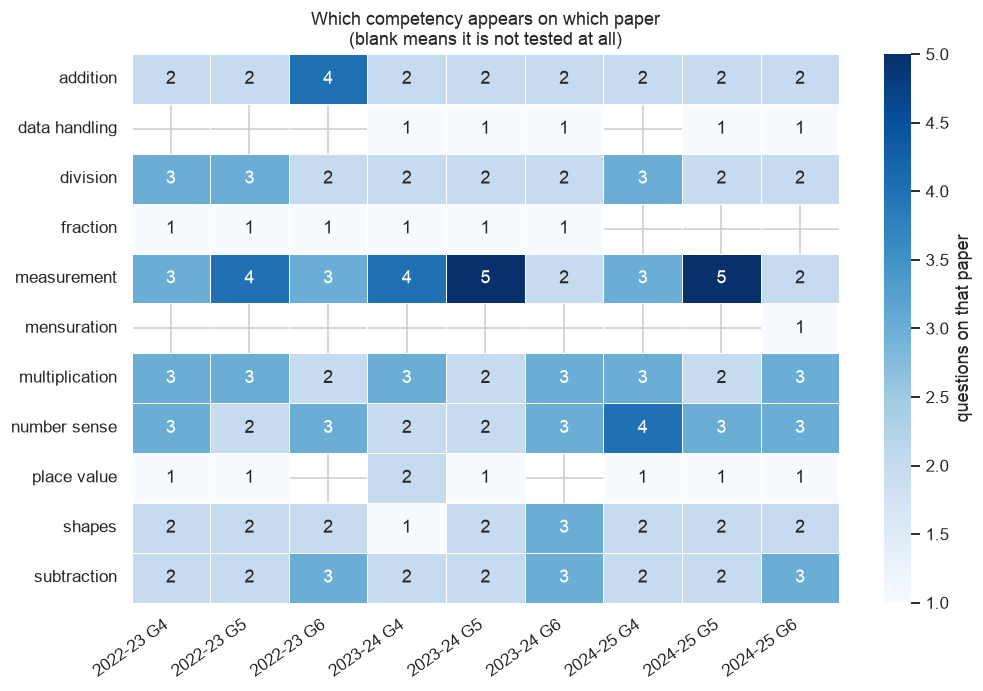

In [8]:
allmaps = pd.concat(MAPS.values(), ignore_index=True)
COMPETENCIES = sorted(allmaps["competency"].dropna().unique())
print(f"{len(COMPETENCIES)} distinct competencies across the nine papers:")
print(", ".join(COMPETENCIES))

cov = (allmaps.pivot_table(index="competency", columns="file", values="qno", aggfunc="count")
       .reindex(COMPETENCIES)[FILE_LABELS])
covi = cov.fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(9.5, .45 * len(covi) + 1.5))
sns.heatmap(covi, annot=True, fmt="d", cmap="Blues", linewidths=.6, mask=(covi == 0),
            cbar_kws={"label": "questions on that paper"}, ax=ax)
ax.set_title("Which competency appears on which paper\n(blank means it is not tested at all)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=35, ha="right")
plt.show()

claim(f"{len(COMPETENCIES)} distinct competencies appear across the nine papers",
      len(COMPETENCIES), "3.1", "count of unique Competency values in all nine mapping sheets")

### 3.2 shared core

only competencies on every paper can be compared across grades/years. scoping everything else locally. also finding stable competencies per grade for trend lines.

In [9]:
present = cov.notna()
CORE = sorted(present.index[present.all(axis=1)])

by_grade = {g: sorted(allmaps.loc[allmaps["Grade"] == g, "competency"].unique()) for g in GRADES}
stable_in_grade = {}
for g in GRADES:
    cols = [f"{y} G{g}" for y in YEARS if (y, g) in MAPS]
    sub = present[cols]
    stable_in_grade[g] = sorted(sub.index[sub.all(axis=1)])

print(f"shared core, on all nine papers ({len(CORE)}): {', '.join(CORE)}\n")
for g in GRADES:
    extra = sorted(set(by_grade[g]) - set(CORE))
    print(f"grade {g}: {len(by_grade[g])} competencies, {len(stable_in_grade[g])} stable across its years"
          + (f", outside the shared core: {extra}" if extra else ""))

claim(f"{len(CORE)} competencies are common to all nine papers and form the shared core",
      len(CORE), "3.2", "intersection of competency sets across the nine mapping sheets")

shared core, on all nine papers (7): addition, division, measurement, multiplication, number sense, shapes, subtraction

grade 4: 10 competencies, 8 stable across its years, outside the shared core: ['data handling', 'fraction', 'place value']
grade 5: 10 competencies, 8 stable across its years, outside the shared core: ['data handling', 'fraction', 'place value']
grade 6: 11 competencies, 7 stable across its years, outside the shared core: ['data handling', 'fraction', 'mensuration', 'place value']


### 3.3 naming consistency

if Q7 changed names between years, they are different items. same for competency labels. pooling them would be wrong.

In [10]:
def stability_table(field):
    rows = []
    for g in GRADES:
        piv = None
        for y in [y for y in YEARS if (y, g) in MAPS]:
            col = MAPS[(y, g)].set_index("qno")[field].rename(y)
            piv = col.to_frame() if piv is None else piv.join(col, how="outer")
        changed = int((piv.nunique(axis=1) > 1).sum())
        rows.append({"Grade": g, "questions": len(piv),
                     "same all years": len(piv) - changed, "changes": changed})
    return pd.DataFrame(rows)

names = stability_table("qname")
comps = stability_table("competency")
print("question NAME across years, within a grade:")
display(names)
print("competency LABEL on the same Q number, across years:")
display(comps)

NAMES_STABLE = bool((names["changes"] == 0).all())
if not NAMES_STABLE:
    print("\nQ numbers do not carry a fixed item across years. So: no analysis below keys "
          "on Q number across files, and section 7 computes name derived features one file "
          "at a time.")

question NAME across years, within a grade:


,Grade,questions,same all years,changes
0,4,20,3,17
1,5,20,1,19
2,6,20,2,18


competency LABEL on the same Q number, across years:


,Grade,questions,same all years,changes
0,4,20,14,6
1,5,20,13,7
2,6,20,13,7



Q numbers do not carry a fixed item across years. So: no analysis below keys on Q number across files, and section 7 computes name derived features one file at a time.


### 3.4 GP coverage per year

if GP set changes, year comparisons reflect coverage, not just learning. running comparisons twice: on everything, and only on common GPs.

,file,Year,Grade,GPs assessed,blocks,districts,children
0,2022-23 G4,2022-23,4,2624,145,30,104015
1,2022-23 G5,2022-23,5,2623,145,30,113164
2,2022-23 G6,2022-23,6,2616,146,30,95523
3,2023-24 G4,2023-24,4,4165,157,28,156940
4,2023-24 G5,2023-24,5,4164,157,28,161979
5,2023-24 G6,2023-24,6,4139,157,28,151938
6,2024-25 G4,2024-25,4,4872,158,28,209867
7,2024-25 G5,2024-25,5,4875,158,28,204008
8,2024-25 G6,2024-25,6,4846,158,28,181653


GPs in every file: 2,360 of 5,034 ever seen (47%)
coverage moves between files, so year comparisons get a common GP twin


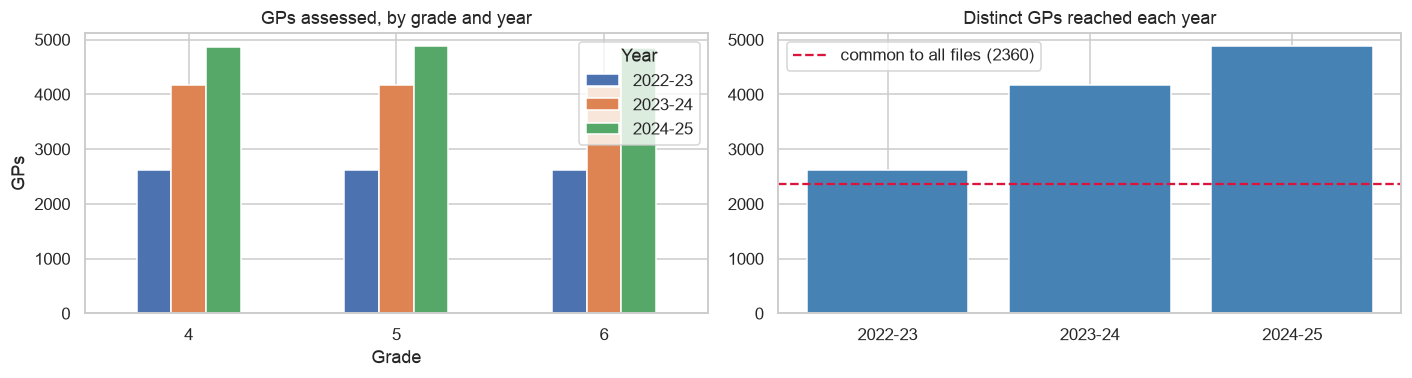

In [11]:
gp_sets = {}
rows = []
for (y, g), geo in GEOS.items():
    s = slice_file(y, g)
    ids = set(geo["GP ID"].dropna()) if (geo is not None and "GP ID" in geo.columns) else set(s["GP ID"].dropna())
    gp_sets[(y, g)] = ids
    rows.append({"file": f"{y} G{g}", "Year": y, "Grade": g,
                 "GPs assessed": s["GP ID"].nunique(), "blocks": s["Block"].nunique(),
                 "districts": s["District"].nunique(), "children": len(s)})
coverage = pd.DataFrame(rows).sort_values(["Year", "Grade"])
display(coverage.reset_index(drop=True))

COMMON_GPS = set.intersection(*gp_sets.values())
ALL_GPS = set.union(*gp_sets.values())
COVERAGE_STABLE = len(COMMON_GPS) == len(ALL_GPS)
print(f"GPs in every file: {len(COMMON_GPS):,} of {len(ALL_GPS):,} ever seen "
      f"({len(COMMON_GPS)/len(ALL_GPS):.0%})")
print("coverage is identical everywhere, no restriction needed" if COVERAGE_STABLE
      else "coverage moves between files, so year comparisons get a common GP twin")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
coverage.pivot(index="Grade", columns="Year", values="GPs assessed").plot(kind="bar", ax=axes[0])
axes[0].set_title("GPs assessed, by grade and year"); axes[0].set_ylabel("GPs")
axes[0].tick_params(axis="x", rotation=0)

per_year = {}
for (y, g), s in gp_sets.items():
    per_year.setdefault(y, set()).update(s)
axes[1].bar(list(per_year), [len(v) for v in per_year.values()], color="steelblue")
axes[1].axhline(len(COMMON_GPS), color="crimson", ls="--", label=f"common to all files ({len(COMMON_GPS)})")
axes[1].set_title("Distinct GPs reached each year"); axes[1].legend()
plt.show()

### 3.5 scope rules

In [12]:
scope = pd.DataFrame([
    ("across grades", f"shared core only, {len(CORE)} competencies"),
    ("across years, within a grade", "competencies present in all three of that grade's papers"),
    ("inside one paper", "everything on it"),
    ("question name features", "per file" if not NAMES_STABLE else "poolable"),
    ("year on year geography", "all GPs plus a common GP version" if not COVERAGE_STABLE else "all GPs"),
], columns=["comparison", "restricted to"])
display(scope)

,comparison,restricted to
0,across grades,"shared core only, 7 competencies"
1,"across years, within a grade",competencies present in all three of that grad...
2,inside one paper,everything on it
3,question name features,per file
4,year on year geography,all GPs plus a common GP version


## 4. sanity checks

### 4.1 columns & identifiers

In [13]:
schemas = {f: set(g.dropna(axis=1, how="all").columns) for f, g in df.groupby("file", observed=True)}
shared_cols = set.intersection(*schemas.values())
missing = {f: sorted(shared_cols ^ cols) for f, cols in schemas.items() if cols != shared_cols}
print(f"{len(shared_cols)} columns common to all nine files")
print("all files carry identical columns" if not missing else f"column differences: {missing}")

vals = pd.unique(df[QPRESENT].to_numpy().ravel())
odd = sorted(v for v in vals if v not in (0, 1, -1))
print("responses outside {0,1}:", odd if odd else "none")
print("cells that were blank in the source (coded -1):", int((df[QPRESENT] == -1).to_numpy().sum()))

uid = "Unique Identifier"
dupes = df.groupby("file", observed=True)[uid].apply(lambda s: int(s.duplicated().sum()))
print(f"\nduplicate identifiers inside a file: {int(dupes.sum())}")
sets = {f: set(g[uid]) for f, g in df.groupby("file", observed=True)}
overlap = max(len(sets[a] & sets[b]) for a, b in combinations(sets, 2))
print(f"most identifiers shared between any two files: {overlap:,}")
print("consistent with the organisers: it is a row label, not a child.")

34 columns common to all nine files
all files carry identical columns
responses outside {0,1}: none
cells that were blank in the source (coded -1): 0

duplicate identifiers inside a file: 0
most identifiers shared between any two files: 0
consistent with the organisers: it is a row label, not a child.


### 4.2 geography hierarchy

In [14]:
def breaks(key, target):
    n = df.groupby(key, observed=True)[target].nunique()
    return n[n > 1]

checks = {f"{k} -> {t}": len(breaks(k, t)) for k, t in
          [("GP ID", "GP Name"), ("GP ID", "Cluster"), ("GP ID", "Block"), ("GP ID", "District"),
           ("GP Name", "GP ID"), ("Cluster", "Block"), ("Block", "District")]}
display(pd.Series(checks, name="rows breaking the rule (want 0)").to_frame())

n_dupe_names = len(breaks("GP Name", "GP ID"))
if n_dupe_names:
    print(f"{n_dupe_names} GP names belong to more than one GP ID, so we group and join on "
          "GP ID everywhere, never on the name.")

,rows breaking the rule (want 0)
GP ID -> GP Name,0
GP ID -> Cluster,1718
GP ID -> Block,41
GP ID -> District,3
GP Name -> GP ID,296
Cluster -> Block,181
Block -> District,2


296 GP names belong to more than one GP ID, so we group and join on GP ID everywhere, never on the name.


### 4.3 district names & revenue divisions

we need performance by division but data doesn't have it. merging official karnataka division mapping. matching on squashed names to handle spelling differences across datasets (KAG, ASER).

In [15]:
def squash(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

DIVISIONS = {
    "Bengaluru": ["Bengaluru Urban", "Bengaluru Rural", "Ramanagara", "Kolar", "Chikkaballapura",
                  "Tumakuru", "Chitradurga", "Davanagere", "Shivamogga"],
    "Mysuru": ["Mysuru", "Mandya", "Hassan", "Chamarajanagara", "Kodagu", "Dakshina Kannada",
               "Udupi", "Chikkamagaluru"],
    "Belagavi": ["Belagavi", "Bagalkote", "Vijayapura", "Dharwad", "Gadag", "Haveri",
                 "Uttara Kannada"],
    "Kalaburagi": ["Kalaburagi", "Bidar", "Yadgir", "Raichur", "Koppal", "Ballari",
                   "Vijayanagara"],
}
ALIASES = {
    # fix spelling diffs for divisions
    "kalburgi": "kalaburagi", "kalaburgi": "kalaburagi",
    "raichuru": "raichur", "kolara": "kolar", "dharwada": "dharwad",
    "yadgiri": "yadgir", "yadagiri": "yadgir", "koppala": "koppal",
    "bagalkot": "bagalkote", "bellary": "ballari", "belgaum": "belagavi",
    "chamarajanagar": "chamarajanagara", "chikkaballapur": "chikkaballapura",
    "vijayanagar": "vijayanagara", "mysore": "mysuru", "shimoga": "shivamogga",
    # karnataka splits revenue into ed districts
    # mapping ed district back to parent division
    
    "belagavichikkodi": "belagavi", "chikkodi": "belagavi",
    "tumakurumadhugiri": "tumakuru", "madhugiri": "tumakuru",
    "uttarakannadasirsi": "uttarakannada", "sirsi": "uttarakannada",
    "uttarakannadakarwar": "uttarakannada", "karwar": "uttarakannada",
}

div_lookup = {}
for div, ds in DIVISIONS.items():
    for d in ds:
        div_lookup[squash(d)] = div

def to_division(name):
    k = squash(name)
    k = ALIASES.get(k, k)
    return div_lookup.get(k, "unmapped")

districts = sorted(df["District"].dropna().astype(str).unique())
df["Division"] = df["District"].astype(str).map(to_division).astype("category")

print(f"{len(districts)} district names in the contest data")
unmapped = sorted(df.loc[df["Division"] == "unmapped", "District"].astype(str).unique())
if unmapped:
    n_lost = int((df["Division"] == "unmapped").sum())
    print(f"!! {len(unmapped)} district names did not match a division, covering "
          f"{n_lost:,} children ({n_lost / len(df):.1%} of the data):")
    for u in unmapped:
        print("   ", u)
    print("   add them to ALIASES above before reading anything divisional")
else:
    print("every district placed in a division")
display(df.groupby("Division", observed=True)
          .agg(districts=("District", "nunique"), children=("Score", "size")))

31 district names in the contest data
every district placed in a division


,districts,children
Division,,
Belagavi,8,419258
Bengaluru,8,333210
Kalaburagi,7,420510
Mysuru,8,206109


In [16]:
# flag duplicate district spellings
import difflib
sus = []
for i, d in enumerate(districts):
    hit = difflib.get_close_matches(d, districts[:i] + districts[i+1:], n=1, cutoff=.88)
    if hit:
        sus.append((d, hit[0]))
print("look alike district names to eyeball before joining anything:", sus if sus else "none")

per_file = {f: set(g["District"].astype(str)) for f, g in df.groupby("file", observed=True)}
missing_somewhere = sorted(set.union(*per_file.values()) - set.intersection(*per_file.values()))
print("districts not present in every file:", missing_somewhere if missing_somewhere else "none")

look alike district names to eyeball before joining anything: none
districts not present in every file: ['chikkamagaluru', 'dakshina kannada', 'udupi', 'uttara kannada sirsi']


## 5. assessment overview

raw scores out of 20 aren't fully comparable across files since items differ. starting here, but section 6 moves to competency level for better comparison.

### 5.1 cohort sizes & score spread

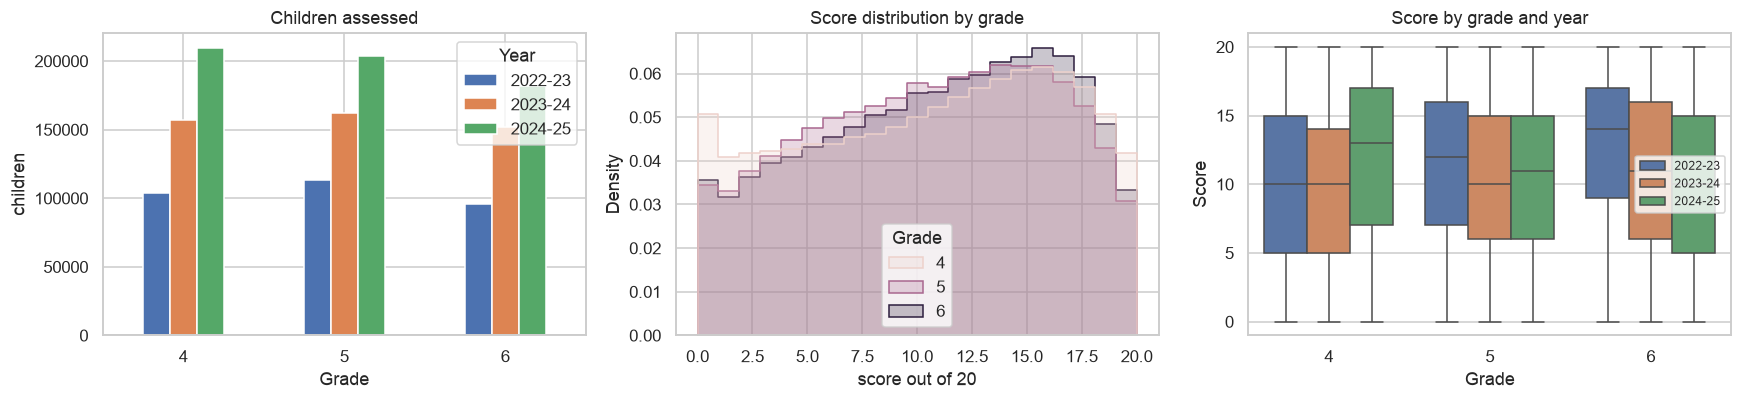

children   mean    sd  median
Grade Year                                  
4     2022-23    104015  9.920 6.010  10.000
      2023-24    156940  9.560 5.660  10.000
      2024-25    209867 11.560 5.970  13.000
5     2022-23    113164 11.230 5.680  12.000
      2023-24    161979 10.270 5.510  10.000
      2024-25    204008 10.340 5.600  11.000
6     2022-23     95523 12.500 5.310  14.000
      2023-24    151938 10.900 5.620  11.000
      2024-25    181653  9.860 5.660  10.000

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
pd.crosstab(df["Grade"], df["Year"]).plot(kind="bar", ax=axes[0])
axes[0].set_title("Children assessed"); axes[0].set_ylabel("children")
axes[0].tick_params(axis="x", rotation=0)

sns.histplot(data=df, x="Score", hue="Grade", element="step", stat="density",
             common_norm=False, bins=21, ax=axes[1])
axes[1].set_title("Score distribution by grade"); axes[1].set_xlabel("score out of 20")

sns.boxplot(data=df, x="Grade", y="Score", hue="Year", ax=axes[2], order=GRADES)
axes[2].set_title("Score by grade and year"); axes[2].legend(fontsize=8, title="")
plt.show()

display(df.groupby(["Grade", "Year"], observed=True)["Score"]
          .agg(children="size", mean="mean", sd="std", median="median").round(2))

### 5.2 is state moving?

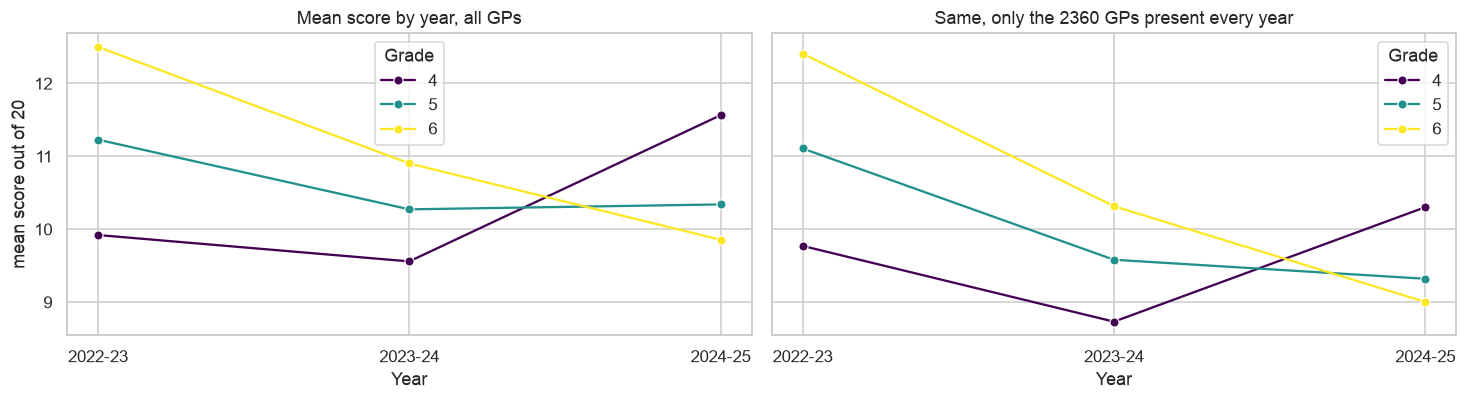

Year,2022-23,2023-24,2024-25,change
Grade,,,,
4,9.920,9.560,11.560,1.640
5,11.230,10.270,10.340,-0.890
6,12.500,10.900,9.860,-2.650


If the two panels disagree, part of what looks like a trend is a change in who was assessed rather than a change in learning.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.8), sharey=True)
t1 = df.groupby(["Year", "Grade"], observed=True, as_index=False)["Score"].mean()
sns.lineplot(data=t1, x="Year", y="Score", hue="Grade", marker="o", ax=axes[0], palette="viridis")
axes[0].set_title("Mean score by year, all GPs"); axes[0].set_ylabel("mean score out of 20")

if not COVERAGE_STABLE:
    t2 = (df[df["GP ID"].isin(COMMON_GPS)]
          .groupby(["Year", "Grade"], observed=True, as_index=False)["Score"].mean())
    sns.lineplot(data=t2, x="Year", y="Score", hue="Grade", marker="o",
                 ax=axes[1], palette="viridis")
    axes[1].set_title(f"Same, only the {len(COMMON_GPS)} GPs present every year")
else:
    axes[1].text(.5, .5, "coverage stable,\nno restriction needed", ha="center", va="center")
    axes[1].axis("off")
plt.show()

chg = t1.pivot(index="Grade", columns="Year", values="Score")
chg["change"] = chg[YEARS[-1]] - chg[YEARS[0]]
display(chg.round(2))
print("If the two panels disagree, part of what looks like a trend is a change in who "
      "was assessed rather than a change in learning.")

### 5.3 gender

hypothesis: girls do better on foundational work but lag on complex problem solving. testing this properly in 7.4 using word problems. here's the headline version.

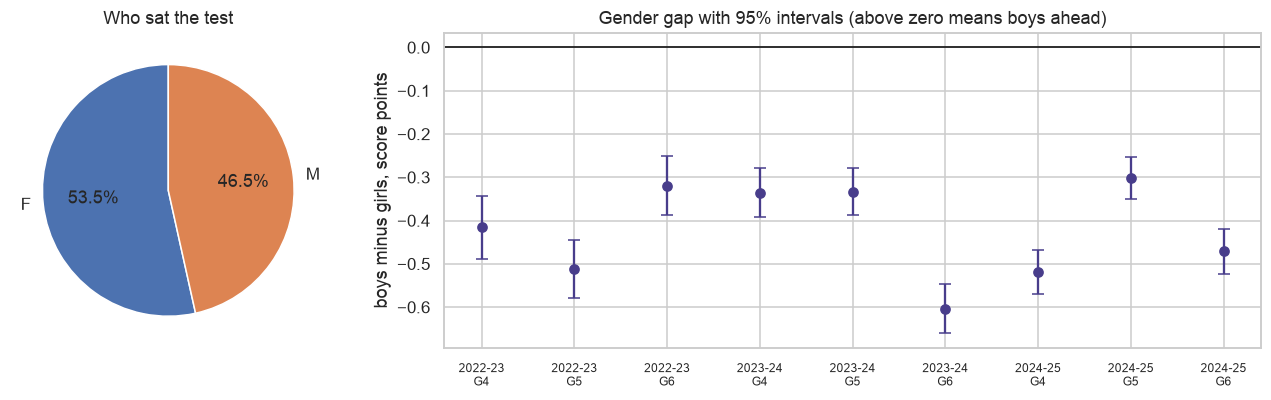

,Year,Grade,boys,girls,boys mean,girls mean,gap (M-F),lo,hi,significant
0,2022-23,4,48057,55958,9.697,10.113,-0.416,-0.489,-0.343,True
1,2022-23,5,52899,60265,10.957,11.468,-0.512,-0.578,-0.445,True
2,2022-23,6,46504,49019,12.338,12.658,-0.319,-0.387,-0.252,True
3,2023-24,4,71971,84969,9.378,9.713,-0.335,-0.392,-0.279,True
4,2023-24,5,74316,87663,10.093,10.426,-0.333,-0.387,-0.279,True
5,2023-24,6,70833,81105,10.581,11.185,-0.604,-0.661,-0.548,True
6,2024-25,4,98392,111475,11.289,11.808,-0.519,-0.570,-0.467,True
7,2024-25,5,93554,110454,10.177,10.480,-0.303,-0.351,-0.254,True
8,2024-25,6,85027,96626,9.606,10.077,-0.471,-0.523,-0.419,True


Pooled gap: -0.406 score points, 95% CI [-0.425, -0.387]


In [19]:
def gap_ci(a, b):
    # mean diff with 95% interval
    d = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    return d, d - 1.96 * se, d + 1.96 * se

rows = []
for (y, g), s in df.groupby(["Year", "Grade"], observed=True):
    m, f = s.loc[s["Gender"] == "M", "Score"], s.loc[s["Gender"] == "F", "Score"]
    if len(m) < 30 or len(f) < 30:
        continue
    d, lo, hi = gap_ci(m, f)
    rows.append({"Year": y, "Grade": g, "boys": len(m), "girls": len(f),
                 "boys mean": m.mean(), "girls mean": f.mean(),
                 "gap (M-F)": d, "lo": lo, "hi": hi,
                 "significant": not (lo <= 0 <= hi)})
gender = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
counts = df["Gender"].value_counts()
axes[0].pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white"})
axes[0].set_title("Who sat the test")

x = np.arange(len(gender))
axes[1].errorbar(x, gender["gap (M-F)"],
                 yerr=[gender["gap (M-F)"] - gender["lo"], gender["hi"] - gender["gap (M-F)"]],
                 fmt="o", capsize=4, color="darkslateblue")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{r.Year}\nG{r.Grade}" for r in gender.itertuples()], fontsize=8)
axes[1].set_ylabel("boys minus girls, score points")
axes[1].set_title("Gender gap with 95% intervals (above zero means boys ahead)")
plt.show()

display(gender.round(3))
overall = gap_ci(df.loc[df["Gender"] == "M", "Score"], df.loc[df["Gender"] == "F", "Score"])
print(f"Pooled gap: {overall[0]:+.3f} score points, 95% CI [{overall[1]:+.3f}, {overall[2]:+.3f}]")
claim("Pooled boys minus girls gap in mean score, all files", overall[0], "5.3",
      "difference of means on Score with a normal approximation interval")

### 5.4 geography

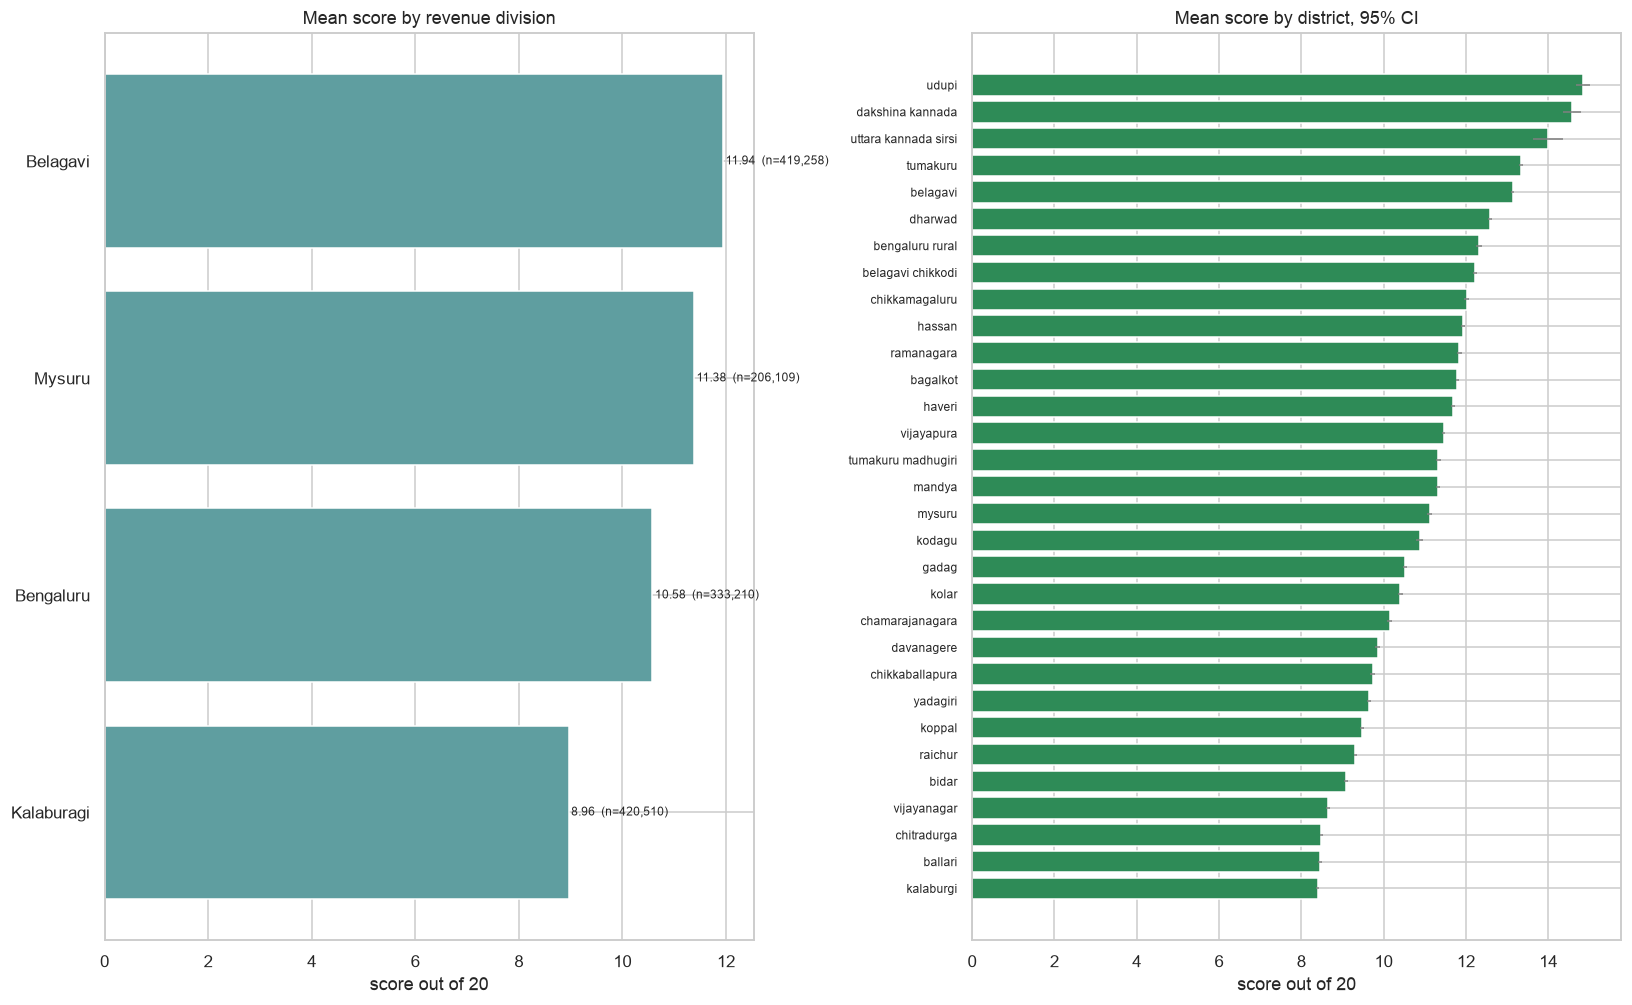

Best district udupi at 14.85, weakest kalaburgi at 8.40, a gap of 6.45 points (32% of the paper).


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, max(4, .30 * df["District"].nunique())))

dv = (df.groupby("Division", observed=True)
        .agg(mean=("Score", "mean"), n=("Score", "size"))
        .sort_values("mean"))
axes[0].barh(dv.index, dv["mean"], color="cadetblue")
axes[0].set_title("Mean score by revenue division")
axes[0].set_xlabel("score out of 20")
for i, (v, n) in enumerate(zip(dv["mean"], dv["n"])):
    axes[0].text(v + .05, i, f"{v:.2f}  (n={n:,})", va="center", fontsize=8)

ds = (df.groupby("District", observed=True)
        .agg(mean=("Score", "mean"), n=("Score", "size"),
             sem=("Score", lambda s: s.std() / np.sqrt(len(s))))
        .sort_values("mean"))
axes[1].barh(ds.index, ds["mean"], xerr=ds["sem"] * 1.96, color="seagreen",
             error_kw={"lw": 1, "ecolor": "grey"})
axes[1].set_title("Mean score by district, 95% CI"); axes[1].set_xlabel("score out of 20")
axes[1].tick_params(axis="y", labelsize=8)
plt.show()

spread = ds["mean"].max() - ds["mean"].min()
print(f"Best district {ds.index[-1]} at {ds['mean'].max():.2f}, "
      f"weakest {ds.index[0]} at {ds['mean'].min():.2f}, a gap of {spread:.2f} points "
      f"({spread/20:.0%} of the paper).")
claim("Spread between the strongest and weakest district mean score", spread, "5.4",
      "max minus min of district mean Score, pooled across all nine files")

### 5.5 learning floor

mean score hides how many kids are failing. counting kids who got less than 50% right. looking at both rate and headcount since budgets are based on headcount.

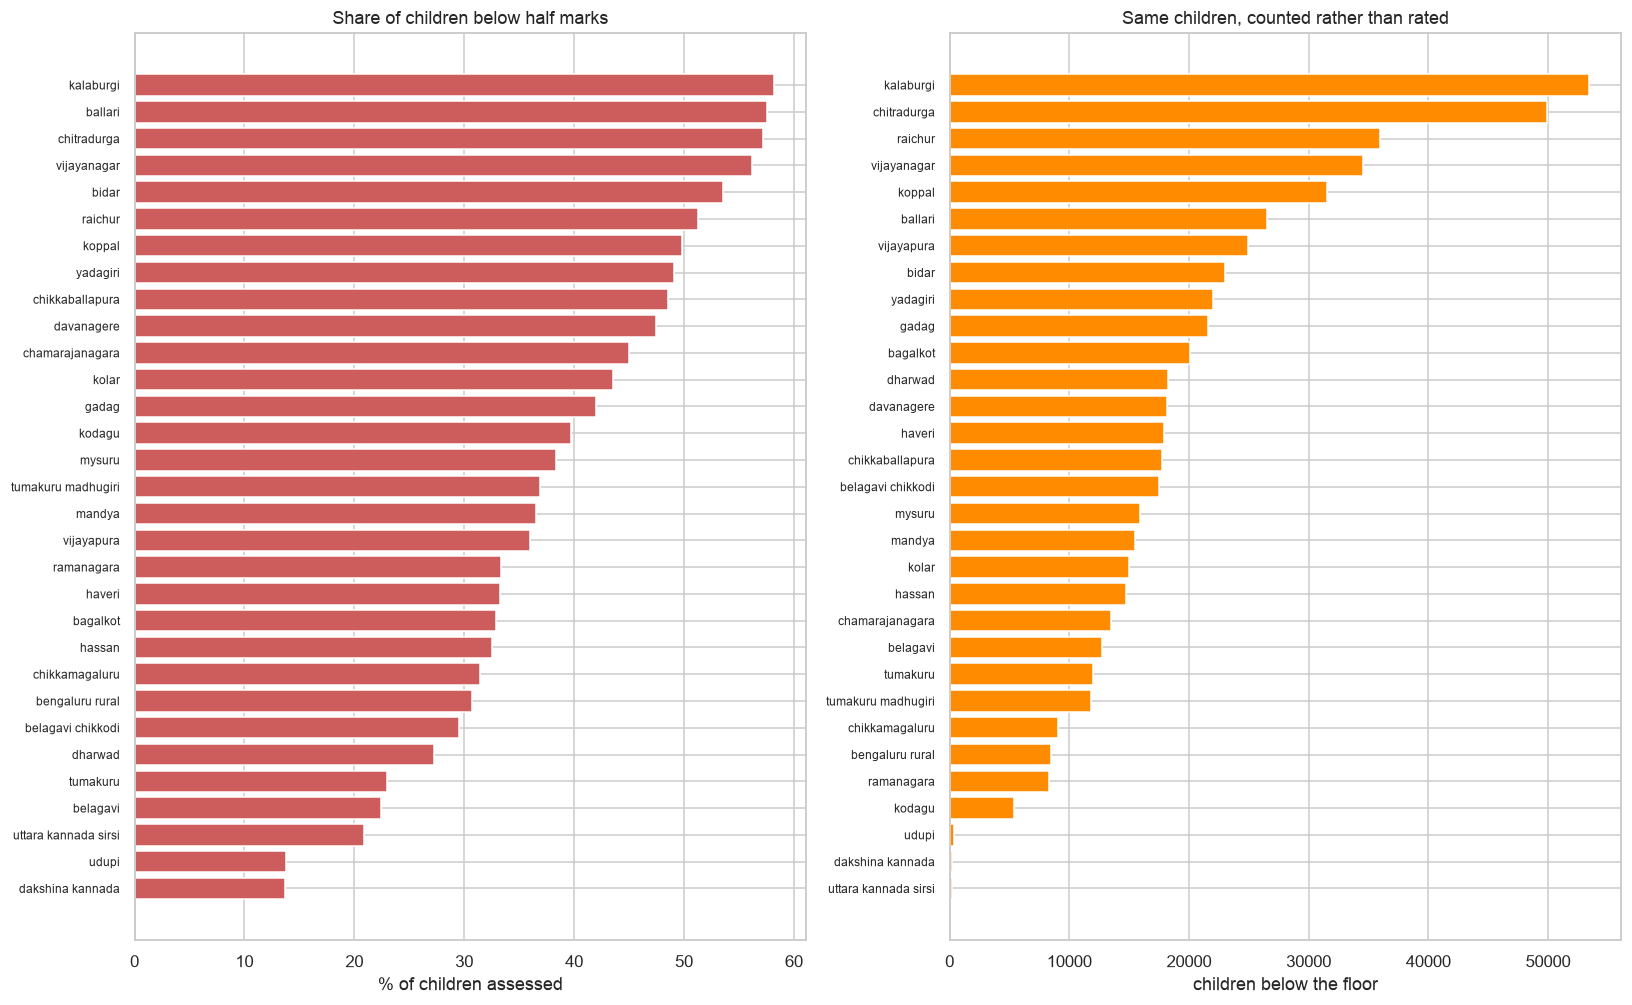

worst five by rate     : ['kalaburgi', 'ballari', 'chitradurga', 'vijayanagar', 'bidar']
worst five by headcount: ['kalaburgi', 'chitradurga', 'raichur', 'vijayanagar', 'koppal']
overlap: ['chitradurga', 'kalaburgi', 'vijayanagar']

Statewide 41.8% of children assessed are below the floor (576,207 children across the three years).


Grade,4,5,6
Year,,,
2022-23,46.400,36.600,27.600
2023-24,49.500,44.400,39.800
2024-25,35.100,44.300,47.300


In [21]:
df["below_floor"] = (df["Score"] < FLOOR * df["n_items"])

floor = (df.groupby("District", observed=True)
           .agg(rate=("below_floor", "mean"), children=("below_floor", "sum"),
                assessed=("below_floor", "size"))
           .sort_values("rate", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, max(4, .30 * len(floor))))
axes[0].barh(floor.index[::-1], floor["rate"][::-1] * 100, color="indianred")
axes[0].set_title("Share of children below half marks")
axes[0].set_xlabel("% of children assessed"); axes[0].tick_params(axis="y", labelsize=8)

byhead = floor.sort_values("children")
axes[1].barh(byhead.index, byhead["children"], color="darkorange")
axes[1].set_title("Same children, counted rather than rated")
axes[1].set_xlabel("children below the floor"); axes[1].tick_params(axis="y", labelsize=8)
plt.show()

top_rate = list(floor.head(5).index)
top_head = list(floor.sort_values("children", ascending=False).head(5).index)
print("worst five by rate     :", top_rate)
print("worst five by headcount:", top_head)
print("overlap:", sorted(set(top_rate) & set(top_head)))
print(f"\nStatewide {df['below_floor'].mean():.1%} of children assessed are below the floor "
      f"({int(df['below_floor'].sum()):,} children across the three years).")
claim("Share of assessed children scoring below half the paper", df["below_floor"].mean(),
      "5.5", "mean of Score < 0.5 * n_items over all rows")

byyear = df.groupby(["Year", "Grade"], observed=True)["below_floor"].mean().unstack()
display((byyear * 100).round(1))

### 5.6 variance location

checking if variation is mostly geographical. splitting variance across admin levels per paper so grade/year differences don't interfere.

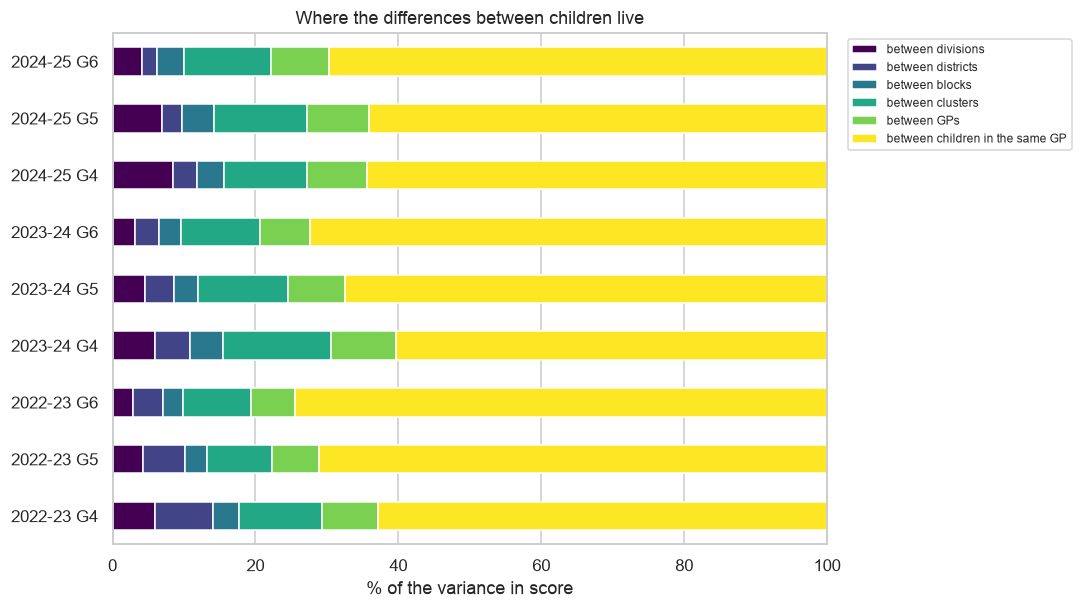

,between divisions,between districts,between blocks,between clusters,between GPs,between children in the same GP
2022-23 G4,5.900,8.200,3.500,11.600,7.800,62.900
2022-23 G5,4.300,5.800,3.100,9.100,6.500,71.100
2022-23 G6,2.900,4.200,2.700,9.500,6.200,74.500
2023-24 G4,5.900,5.000,4.600,15.100,9.100,60.400
2023-24 G5,4.600,4.000,3.400,12.600,7.900,67.500
2023-24 G6,3.200,3.400,3.000,11.100,7.000,72.400
2024-25 G4,8.500,3.300,3.800,11.500,8.400,64.400
2024-25 G5,6.900,2.800,4.600,12.900,8.700,64.100
2024-25 G6,4.100,2.100,3.800,12.200,8.200,69.700


On average 67% of the variation is between children inside the same GP and only 33% is geographic.
Reading: choosing districts well is worth something, but the larger share of the problem sits inside classrooms that geography cannot see. Targeting has to be paired with something that differentiates within a classroom.


In [22]:
LEVELS = {"between divisions": ["Division"],
          "between districts": ["Division", "District"],
          "between blocks": ["Division", "District", "Block"],
          "between clusters": ["Division", "District", "Block", "Cluster"],
          "between GPs": ["Division", "District", "Block", "Cluster", "GP ID"]}

def decompose(sub, col="Score"):
    total = sub[col].var()
    out, prev = {}, 0.0
    for label, keys in LEVELS.items():
        r2 = sub.groupby(keys, observed=True)[col].transform("mean").var() / total
        out[label] = max(r2 - prev, 0.0)
        prev = max(r2, prev)
    out["between children in the same GP"] = max(1 - prev, 0.0)
    return pd.Series(out)

vd = pd.DataFrame({f"{y} G{g}": decompose(slice_file(y, g)) for y, g in FILES}).T * 100

fig, ax = plt.subplots(figsize=(10, 3 + .3 * len(vd)))
vd.plot(kind="barh", stacked=True, ax=ax, colormap="viridis")
ax.set_xlim(0, 100); ax.set_xlabel("% of the variance in score")
ax.set_title("Where the differences between children live")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.show()
display(vd.round(1))

within = vd["between children in the same GP"].mean()
geo = 100 - within
print(f"On average {within:.0f}% of the variation is between children inside the same GP "
      f"and only {geo:.0f}% is geographic.")
print("Reading: choosing districts well is worth something, but the larger share of the "
      "problem sits inside classrooms that geography cannot see. Targeting has to be paired "
      "with something that differentiates within a classroom.")
claim("Share of score variance sitting between children within the same GP",
      within / 100, "5.6", "mean across the nine papers of the residual after nested group means")

## 6. competency level

moving to per child competency scores (fraction correct on their paper). averaging weights every child equally.

In [23]:
ID_KEEP = ["Year", "Grade", "file", "Division", "District", "Block", "Cluster",
           "GP ID", "Gender", "Score", "n_items", "row_id", "below_floor"]

def build_competency_scores():
    out = []
    for (y, g), m in MAPS.items():
        s = slice_file(y, g)
        base = s[ID_KEEP].copy()
        vals = s[[q for q in m["qno"] if q in s.columns]].astype("float32")
        vals = vals.mask(vals < 0)
        for comp, grp in m.groupby("competency"):
            cols = [q for q in grp["qno"] if q in vals.columns]
            base[comp] = vals[cols].mean(axis=1).astype("float32")
        out.append(base)
    return pd.concat(out, ignore_index=True)

cs = build_competency_scores()
COMP_COLS = [c for c in COMPETENCIES if c in cs.columns]

def mastery(frame, keys, comps=None):
    cols = [c for c in (comps or COMP_COLS) if c in frame.columns]
    wide = frame.groupby(keys, observed=True)[cols].mean().reset_index()
    return (wide.melt(id_vars=keys, var_name="competency", value_name="mastery")
                .dropna(subset=["mastery"]))

print(f"{len(cs):,} children x {len(COMP_COLS)} competency columns "
      f"({cs[COMP_COLS].memory_usage(deep=True).sum()/1e6:.0f} MB)")
cs.head(3)

1,379,087 children x 11 competency columns (61 MB)


,Year,Grade,file,Division,District,Block,Cluster,GP ID,Gender,Score,n_items,row_id,below_floor,addition,division,fraction,measurement,multiplication,number sense,place value,shapes,subtraction,data handling,mensuration
0,2022-23,4,2022-23 G4,Belagavi,belagavi,bailhongal,ambadgatti,648,F,16,20,0,False,1.000,0.333,1.000,1.000,1.000,1.000,1.000,0.500,0.500,NaN,NaN
1,2022-23,4,2022-23 G4,Belagavi,belagavi,bailhongal,ambadgatti,648,F,11,20,1,False,1.000,0.667,0.000,0.000,0.667,0.667,1.000,0.500,0.500,NaN,NaN
2,2022-23,4,2022-23 G4,Belagavi,belagavi,bailhongal,ambadgatti,648,F,10,20,2,False,0.000,0.000,1.000,0.667,0.333,1.000,0.000,1.000,0.500,NaN,NaN


### 6.1 weakest competencies

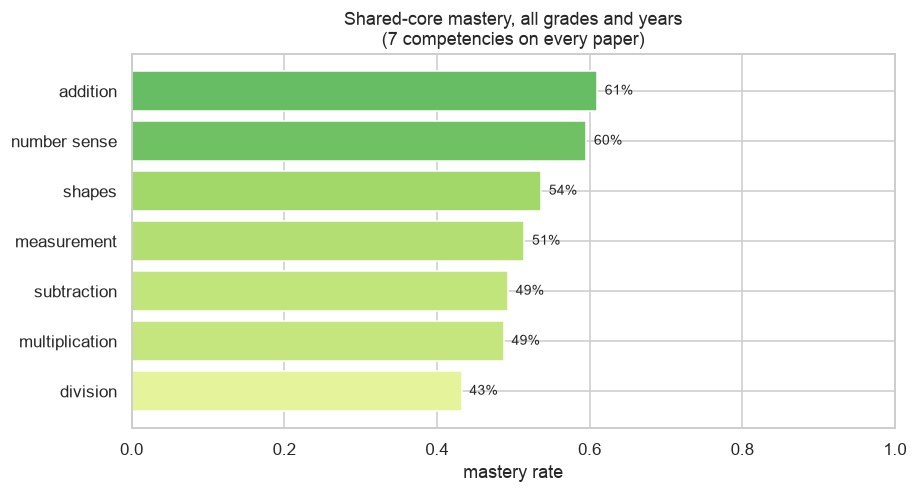

,mastery,items across all papers
division,0.433,21
multiplication,0.488,24
subtraction,0.493,21
measurement,0.515,31
shapes,0.537,18
number sense,0.596,25
addition,0.610,20


In [24]:
core_state = (cs[COMP_COLS].mean()[CORE].sort_values().rename("mastery").to_frame())
core_state["items across all papers"] = (allmaps[allmaps["competency"].isin(CORE)]
                                         .groupby("competency").size())

fig, ax = plt.subplots(figsize=(8.5, .45 * len(core_state) + 1.5))
ax.barh(core_state.index, core_state["mastery"],
        color=plt.cm.RdYlGn(core_state["mastery"] / core_state["mastery"].max() * .8))
ax.set_xlim(0, 1); ax.set_xlabel("mastery rate")
ax.set_title(f"Shared core mastery, all grades and years\n({len(CORE)} competencies on every paper)")
for i, r in enumerate(core_state.itertuples()):
    ax.text(r.mastery + .01, i, f"{r.mastery:.0%}", va="center", fontsize=9)
plt.show()
display(core_state.round(3))

weakest = core_state.index[0]
claim(f"Weakest shared core competency statewide is {weakest}",
      core_state["mastery"].iloc[0], "6.1", "mean of per child competency fraction, all files")

### 6.2 central vs local fix

if a competency is weak everywhere evenly, it's a curriculum problem. if it's uneven across districts, it's a delivery problem.
plotting mean vs spread to separate these. bottom left quadrant is a central fix.

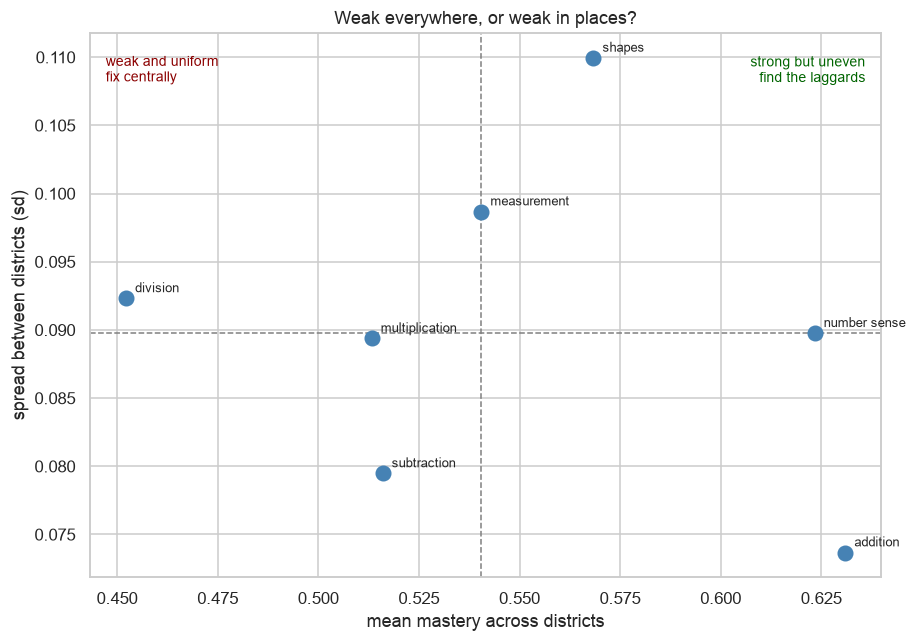

weak and uniform, so a curriculum side fix: ['multiplication', 'subtraction']
weak and uneven, so a delivery side fix   : ['division']


In [25]:
bydist = mastery(cs, ["District"])
quad = (bydist.groupby("competency")["mastery"]
        .agg(mean="mean", sd="std", lo="min", hi="max")
        .assign(spread=lambda d: d["hi"] - d["lo"]))
quad = quad.loc[[c for c in CORE if c in quad.index]]

mx, my = quad["mean"].median(), quad["sd"].median()
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(quad["mean"], quad["sd"], s=90, color="steelblue", zorder=3)
for c, r in quad.iterrows():
    ax.annotate(c, (r["mean"], r["sd"]), fontsize=8.5,
                xytext=(6, 4), textcoords="offset points")
ax.axvline(mx, color="grey", ls="--", lw=1); ax.axhline(my, color="grey", ls="--", lw=1)
ax.set_xlabel("mean mastery across districts"); ax.set_ylabel("spread between districts (sd)")
ax.set_title("Weak everywhere, or weak in places?")
ax.text(.02, .96, "weak and uniform\nfix centrally", transform=ax.transAxes, fontsize=9,
        color="darkred", va="top")
ax.text(.98, .96, "strong but uneven\nfind the laggards", transform=ax.transAxes, fontsize=9,
        color="darkgreen", va="top", ha="right")
plt.show()

central = quad[(quad["mean"] < mx) & (quad["sd"] < my)].index.tolist()
local = quad[(quad["mean"] < mx) & (quad["sd"] >= my)].index.tolist()
print("weak and uniform, so a curriculum side fix:", central if central else "none")
print("weak and uneven, so a delivery side fix   :", local if local else "none")
claim("Competencies that are below median mastery and below median spread, i.e. centrally fixable",
      ", ".join(central), "6.2", "quadrant split on district level mastery mean vs sd")

### 6.3 mastery grade 4 to 6

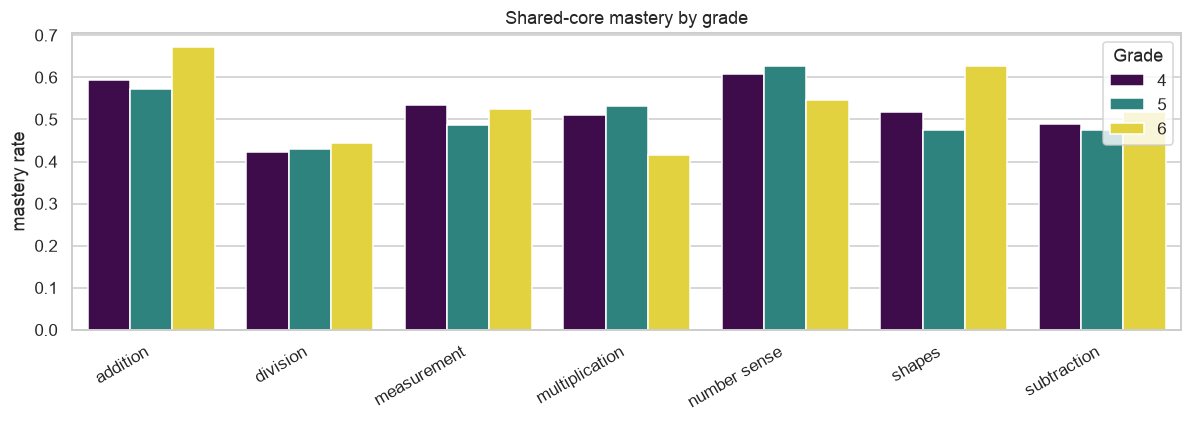

Grade,4,5,6,G4 to G6
competency,,,,
multiplication,0.510,0.532,0.415,-0.095
number sense,0.608,0.627,0.547,-0.062
measurement,0.534,0.487,0.524,-0.010
division,0.423,0.431,0.445,0.021
subtraction,0.490,0.474,0.518,0.029
addition,0.593,0.571,0.672,0.078
shapes,0.519,0.474,0.626,0.107


Barely moves across two years of schooling: ['measurement', 'multiplication', 'number sense']
Careful: different children sat the different papers, so this is a comparison of cohorts, not of the same child two years later.


In [26]:
cg = mastery(cs, ["Grade"], CORE)
fig, ax = plt.subplots(figsize=(11, 4))
sns.barplot(data=cg, x="competency", y="mastery", hue="Grade", ax=ax, palette="viridis")
ax.set_title("Shared core mastery by grade"); ax.set_xlabel(""); ax.set_ylabel("mastery rate")
plt.xticks(rotation=30, ha="right"); plt.show()

piv = cg.pivot(index="competency", columns="Grade", values="mastery")
piv["G4 to G6"] = piv[GRADES[-1]] - piv[GRADES[0]]
display(piv.sort_values("G4 to G6").round(3))
flat = piv[piv["G4 to G6"] <= 0.02].index.tolist()
print("Barely moves across two years of schooling:", flat if flat else "none")
print("Careful: different children sat the different papers, so this is a comparison of "
      "cohorts, not of the same child two years later.")

### 6.4 gender gap per competency

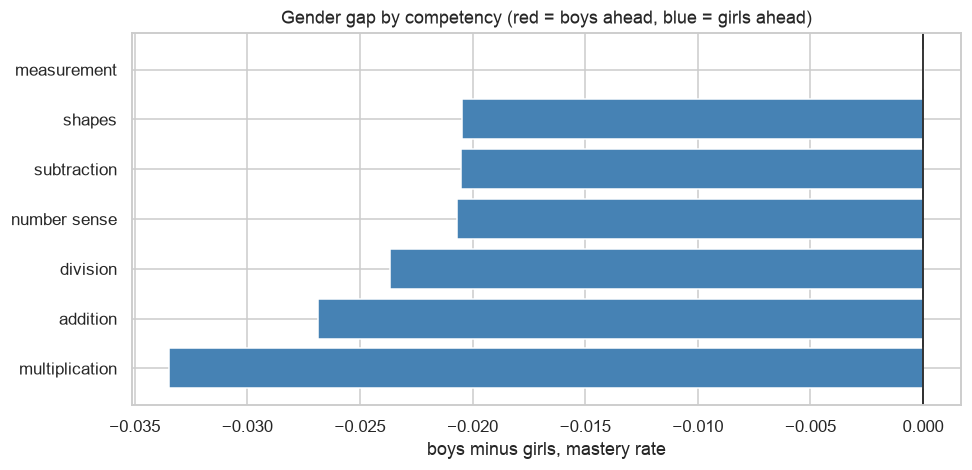

Gender,F,M,gap
competency,,,
multiplication,0.503,0.470,-0.033
addition,0.622,0.596,-0.027
division,0.444,0.420,-0.024
number sense,0.605,0.585,-0.021
subtraction,0.503,0.482,-0.020
shapes,0.546,0.526,-0.020
measurement,0.515,0.515,0.000


Sign changes across competencies matter more than the overall average: a single state level gender number would average these out to almost nothing.


In [27]:
gsplit = mastery(cs, ["Gender"], CORE).pivot(index="competency", columns="Gender", values="mastery")
gsplit["gap"] = gsplit["M"] - gsplit["F"]
gsplit = gsplit.sort_values("gap")

fig, ax = plt.subplots(figsize=(9, .42 * len(gsplit) + 1.5))
ax.barh(gsplit.index, gsplit["gap"],
        color=["indianred" if v > 0 else "steelblue" for v in gsplit["gap"]])
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("boys minus girls, mastery rate")
ax.set_title("Gender gap by competency (red = boys ahead, blue = girls ahead)")
plt.show()
display(gsplit.round(3))
print("Sign changes across competencies matter more than the overall average: a single "
      "state level gender number would average these out to almost nothing.")

### 6.5 district by competency

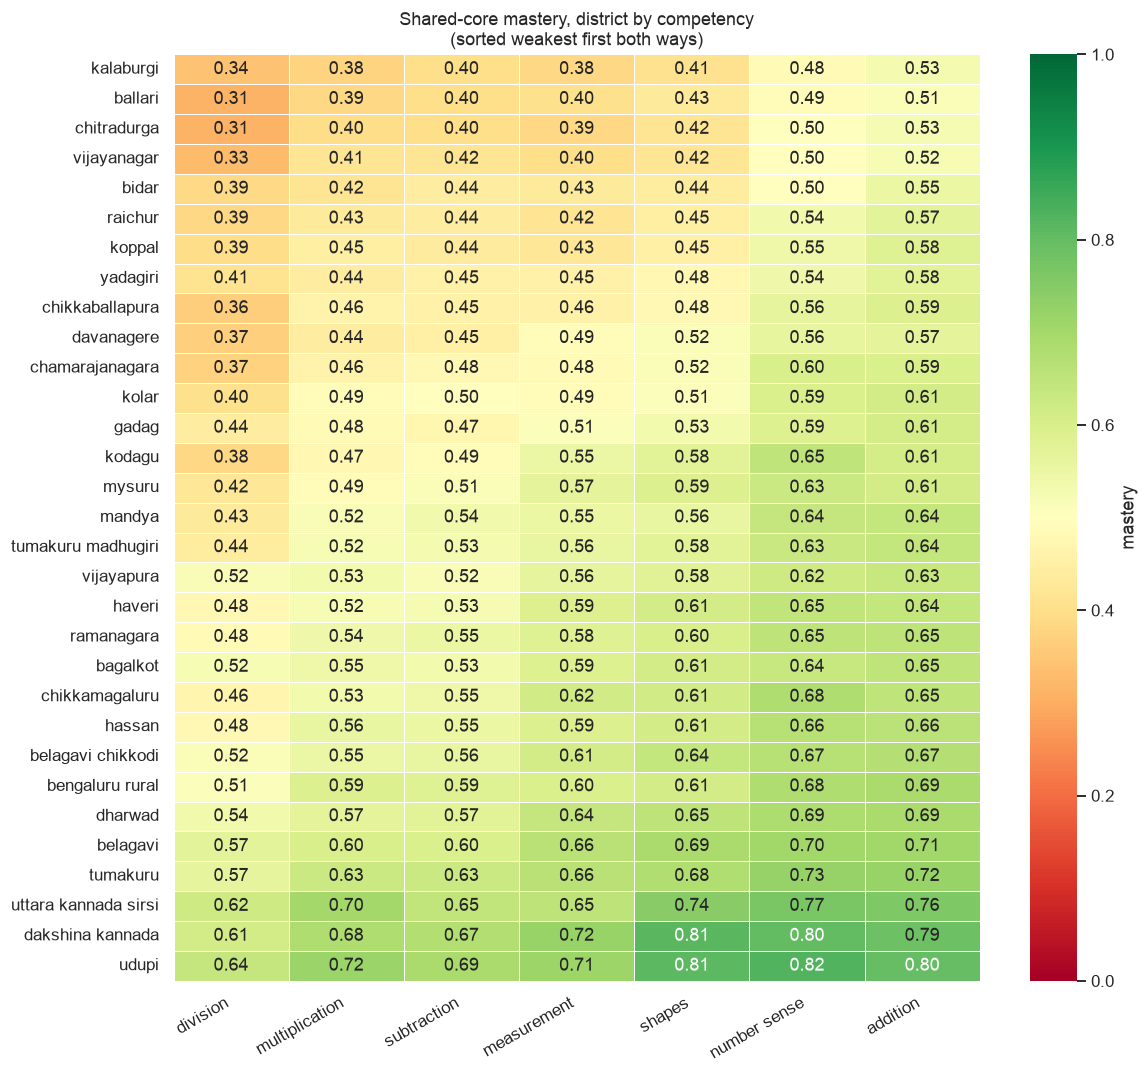

Weakest single cell: division in ballari at 31%.


In [28]:
hm = bydist.pivot(index="District", columns="competency", values="mastery")
hm = hm[[c for c in CORE if c in hm.columns]]
hm = hm.loc[hm.mean(axis=1).sort_values().index, hm.mean(axis=0).sort_values().index]

fig, ax = plt.subplots(figsize=(11, max(4, .32 * len(hm))))
sns.heatmap(hm, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, linewidths=.4,
            cbar_kws={"label": "mastery"}, ax=ax)
ax.set_title("Shared core mastery, district by competency\n(sorted weakest first both ways)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.xticks(rotation=30, ha="right"); plt.show()

worst = hm.stack().idxmin()
print(f"Weakest single cell: {worst[1]} in {worst[0]} at {hm.stack().min():.0%}.")

### 6.6 trends across years

mastery can shift just because questions changed. checking item survival across years before looking at trends.

In [29]:
qmeta = (allmaps.rename(columns={"qname": "question_name"})
         .assign(file=lambda d: d["Year"] + " G" + d["Grade"].astype(str)))

def norm_name(n):
    n = str(n).strip().lower().replace(" ", "")
    n = n.replace("wordproblem", "word_problem")
    n = re.sub(r"(seeing|using)_pictures?", "seeing_pictures", n)
    n = re.sub(r"_?\(", "(", n)
    n = re.sub(r"\b2-d", "2d", n)
    n = re.sub(r"\b3-d", "3d", n)
    n = re.sub(r"_+", "_", n).strip("_-")
    return n

qmeta["name"] = qmeta["question_name"].map(norm_name)
raw_n, norm_n = qmeta["question_name"].nunique(), qmeta["name"].nunique()
print(f"question names: {raw_n} as written, {norm_n} after tidying up the spelling variants")

variants = (qmeta.groupby("name")["question_name"].unique())
variants = variants[variants.map(len) > 1]
for k, v in variants.items():
    print(f"  {k}  <-  {list(v)}")

question names: 70 as written, 65 after tidying up the spelling variants
  addition_with_carry(abstract)  <-  ['addition_with_carry(abstract)', 'addition_with_carry_(abstract)']
  addition_with_carry(word_problem)  <-  ['addition_with_carry_(word_problem)', 'addition_with_carry_(wordproblem)']
  long_multiplication(abstract)  <-  ['long_multiplication(abstract)', 'long_multiplication_(abstract)']
  subtraction_with_borrow(abstract)  <-  ['subtraction_with_borrow(abstract)', 'subtraction_with_borrow_(abstract)']
  subtraction_without_borrow(seeing_pictures)  <-  ['subtraction_without_borrow_(seeing_pictures)', 'subtraction_without_borrow_(seeing_picture)']


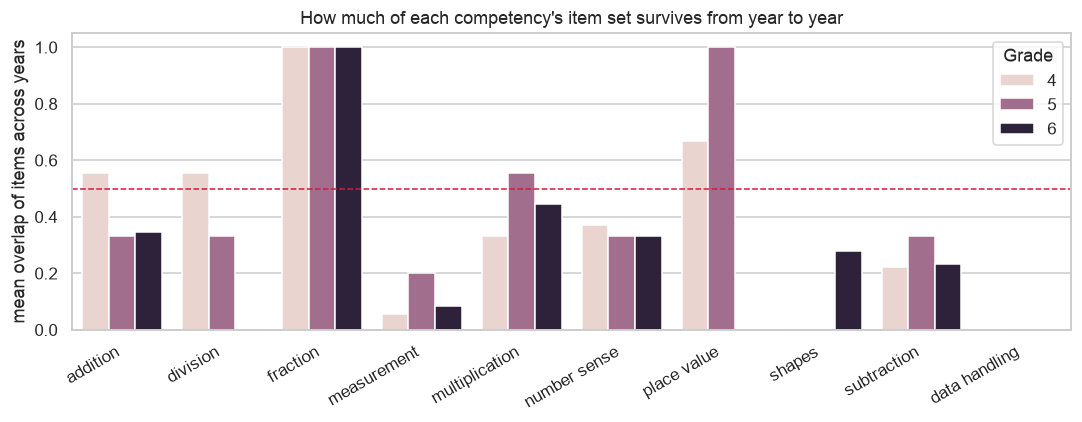

competencies whose items are largely swapped out between years: ['addition', 'data handling', 'division', 'measurement', 'multiplication', 'number sense', 'shapes', 'subtraction']

2 question(s) sit under different competencies in different files:
  fractions_seeing_pictures                    2022-23 G4   -> fraction
  fractions_seeing_pictures                    2022-23 G5   -> fraction
  fractions_seeing_pictures                    2022-23 G6   -> fraction
  fractions_seeing_pictures                    2023-24 G4   -> fraction
  fractions_seeing_pictures                    2023-24 G5   -> fraction
  fractions_seeing_pictures                    2023-24 G6   -> fraction
  fractions_seeing_pictures                    2024-25 G4   -> number sense
  fractions_seeing_pictures                    2024-25 G5   -> number sense
  fractions_seeing_pictures                    2024-25 G6   -> number sense
  mensuration(area,perimeter,circumference,radius,diameter_etc) 2022-23 G6   -> measurement


In [30]:
rows = []
for g in GRADES:
    sub = qmeta[qmeta["Grade"] == g]
    for comp in sorted(sub["competency"].unique()):
        sets = {y: set(sub.loc[(sub["Year"] == y) & (sub["competency"] == comp), "name"])
                for y in YEARS}
        sets = {y: s for y, s in sets.items() if s}
        if len(sets) < 2:
            overlap = np.nan
        else:
            sims = [len(sets[a] & sets[b]) / len(sets[a] | sets[b]) for a, b in combinations(sets, 2)]
            overlap = float(np.mean(sims))
        rows.append({"Grade": g, "competency": comp, "years present": len(sets),
                     "item overlap": overlap})
comp_stab = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=comp_stab.dropna(subset=["item overlap"]), x="competency", y="item overlap",
            hue="Grade", ax=ax)
ax.axhline(.5, color="crimson", ls="--", lw=1)
ax.set_ylabel("mean overlap of items across years"); ax.set_xlabel("")
ax.set_title("How much of each competency's item set survives from year to year")
plt.xticks(rotation=30, ha="right"); plt.show()

SHAKY = sorted(comp_stab.loc[comp_stab["item overlap"] < .5, "competency"].unique())
print("competencies whose items are largely swapped out between years:", SHAKY if SHAKY else "none")

moved = qmeta.groupby("name")["competency"].nunique()
moved = moved[moved > 1]
if len(moved):
    print(f"\n{len(moved)} question(s) sit under different competencies in different files:")
    for nm in moved.index:
        for r in qmeta[qmeta["name"] == nm].sort_values("file").itertuples():
            print(f"  {nm:44s} {r.file:12s} -> {r.competency}")
    print("\nAny trend in those competencies is partly bookkeeping. Use the item level trend below.")

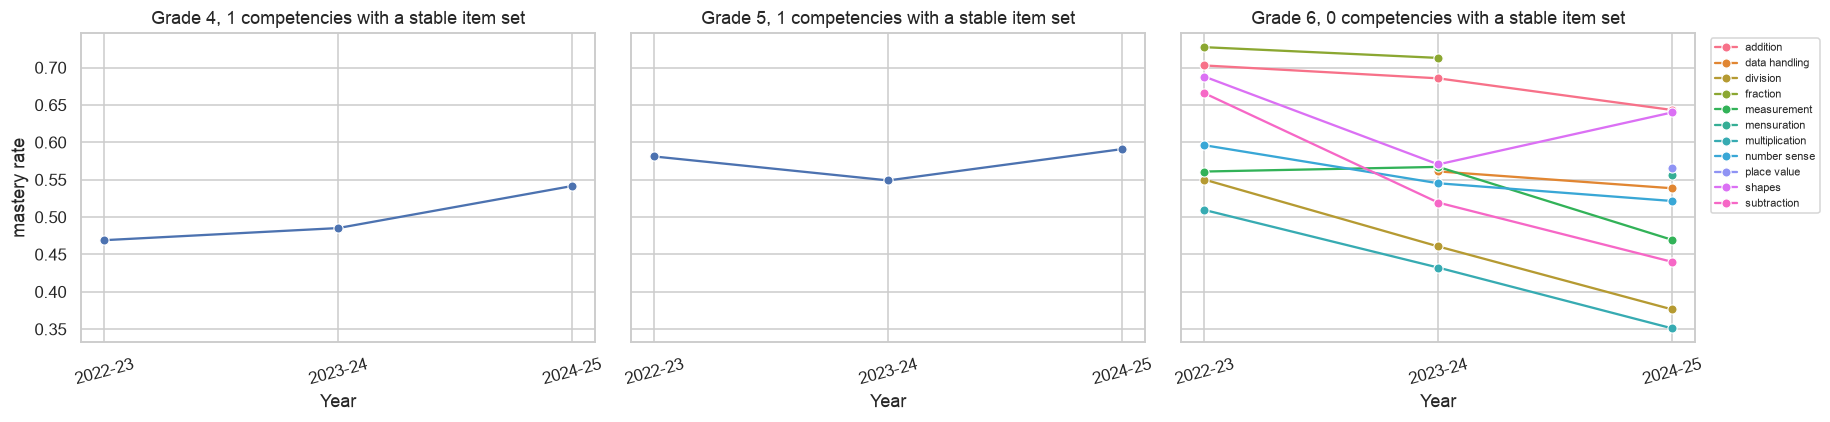

Restricted twice over: only competencies present in all three years of that grade, and only those whose item set holds together.


In [31]:
fig, axes = plt.subplots(1, len(GRADES), figsize=(5.6 * len(GRADES), 4), squeeze=False, sharey=True)
for ax, g in zip(axes[0], GRADES):
    keep = [c for c in stable_in_grade[g] if c not in SHAKY]
    sub = mastery(cs[cs["Grade"] == g], ["Year"], keep)
    sns.lineplot(data=sub, x="Year", y="mastery", hue="competency", marker="o", ax=ax,
                 legend=(ax is axes[0][-1]))
    ax.set_title(f"Grade {g}, {len(keep)} competencies with a stable item set")
    ax.set_ylabel("mastery rate" if ax is axes[0][0] else "")
    ax.tick_params(axis="x", rotation=15)
if axes[0][-1].get_legend():
    axes[0][-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
plt.show()
print("Restricted twice over: only competencies present in all three years of that grade, "
      "and only those whose item set holds together.")

cleanest trend is item level: same question, grade, multiple years. immune to relabelling/composition changes. trust this if they disagree.

36 grade item combinations appear in more than one year


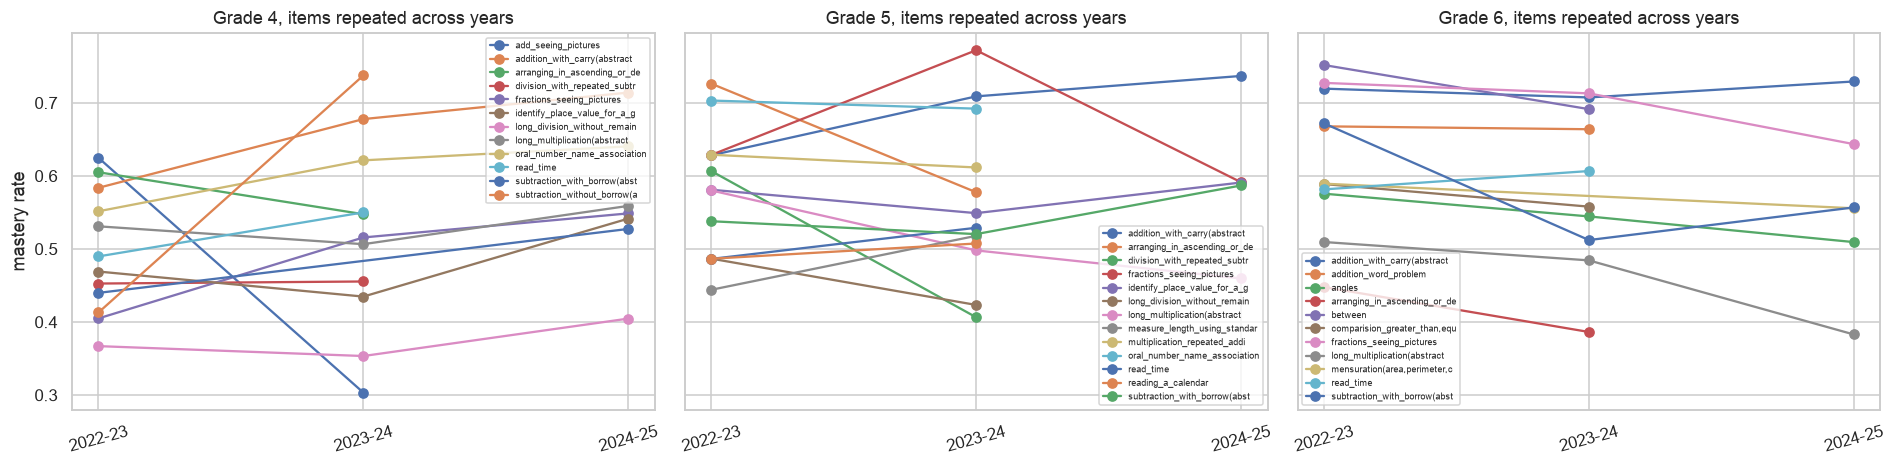

Year                                                      2022-23  2023-24  2024-25  change
Grade name                                                                                 
6     long_multiplication(abstract)                         0.509    0.484    0.383  -0.127
5     long_multiplication(abstract)                         0.580    0.498    0.460  -0.120
6     subtraction_with_borrow(abstract)                     0.672    0.512    0.557  -0.115
      fractions_seeing_pictures                             0.727    0.713    0.643  -0.084
      angles                                                0.576    0.545    0.509  -0.066
5     fractions_seeing_pictures                             0.629    0.772    0.591  -0.037
6     mensuration(area,perimeter,circumference,radius...    0.589      NaN    0.556  -0.034
      addition_with_carry(abstract)                         0.719    0.707    0.729   0.010
5     identify_place_value_for_a_given_number               0.581    0.549    0.591   0.010
4     long_multiplication(abstract)                         0.531    0.507    0.559   0.028
      long_division_without_remainder                       0.367    0.353    0.405   0.038
5     subtraction_with_borrow(abstract)                     0.538    0.520    0.587   0.049
4     identify_place_value_for_a_given_number               0.469    0.435    0.542   0.072
      subtraction_with_borrow(abstract)                     0.440      NaN    0.527   0.088
      oral_number_name_association                          0.552    0.621    0.640   0.089
5     addition_with_carry(abstract)                         0.628    0.709    0.737   0.109
4     addition_with_carry(abstract)                         0.584    0.678    0.714   0.130
      fractions_seeing_pictures                             0.405    0.516    0.549   0.144
      add_seeing_pictures                                   0.625    0.303      NaN     NaN
      arranging_in_ascending_or_descending_order            0.605    0.548      NaN     NaN
      division_with_repeated_subtraction                    0.453    0.455      NaN     NaN
      read_time                                             0.490    0.550      NaN     NaN
      subtraction_without_borrow(abstract)                  0.413    0.737      NaN     NaN
5     arranging_in_ascending_or_descending_order            0.726    0.578      NaN     NaN
      division_with_repeated_subtraction                    0.607    0.407      NaN     NaN
      long_division_without_remainder                       0.487    0.423      NaN     NaN
      measure_length_using_standard_unit                    0.444    0.518      NaN     NaN
      multiplication_repeated_addition                      0.629    0.612      NaN     NaN
      oral_number_name_association                          0.703    0.692      NaN     NaN
      read_time                                             0.486    0.529      NaN     NaN
      reading_a_calendar                                    0.487    0.507      NaN     NaN
6     addition_word_problem                                 0.668    0.664      NaN     NaN
      arranging_in_ascending_or_descending_order            0.448    0.386      NaN     NaN
      between                                               0.752    0.691      NaN     NaN
      comparision_greater_than,equal_to_and_lesser_th...    0.589    0.558      NaN     NaN
      read_time                                             0.582    0.607      NaN     NaN

In [32]:
item_rows = []
for (y, g), m in MAPS.items():
    s = slice_file(y, g)
    v = s[[q for q in m["qno"] if q in s.columns]].astype("float32").mask(lambda x: x < 0)
    means = v.mean()
    for _, r in m.iterrows():
        if r["qno"] in means.index:
            item_rows.append({"Grade": g, "Year": y, "name": norm_name(r["qname"]),
                              "mastery": means[r["qno"]], "competency": r["competency"]})
items = pd.DataFrame(item_rows).groupby(["Grade", "Year", "name"], as_index=False)["mastery"].mean()

seen = items.groupby(["Grade", "name"])["Year"].nunique()
repeat = seen[seen > 1].reset_index()[["Grade", "name"]]
tracked = items.merge(repeat, on=["Grade", "name"])
print(f"{len(repeat)} grade item combinations appear in more than one year")

if len(tracked):
    fig, axes = plt.subplots(1, len(GRADES), figsize=(5.8 * len(GRADES), 4.4),
                             squeeze=False, sharey=True)
    for ax, g in zip(axes[0], GRADES):
        sub = tracked[tracked["Grade"] == g]
        for nm, grp in sub.groupby("name"):
            ax.plot(grp["Year"], grp["mastery"], marker="o", label=nm[:28])
        ax.set_title(f"Grade {g}, items repeated across years")
        ax.set_ylabel("mastery rate" if ax is axes[0][0] else "")
        ax.tick_params(axis="x", rotation=15)
        ax.legend(fontsize=6)
    plt.show()

    tp = tracked.pivot_table(index=["Grade", "name"], columns="Year", values="mastery")
    if YEARS[0] in tp.columns and YEARS[-1] in tp.columns:
        tp["change"] = tp[YEARS[-1]] - tp[YEARS[0]]
        display(tp.sort_values("change").round(3))

## 7. question details

question names have more detail than competency labels (e.g., `subtraction_with_borrow_(word_problem)`).
we can test specific skills if we change one factor at a time.

note: comparing "pictorial" vs "abstract" inside a competency fails if one has a carry and the other doesn't. holding one factor constant below.

### 7.1 parsing names

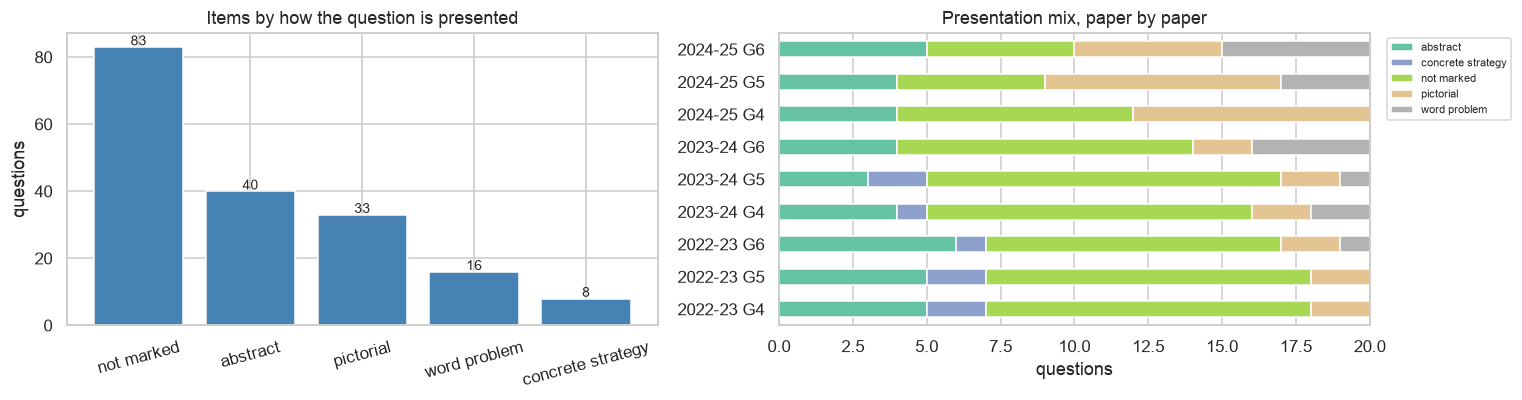

mode,abstract,concrete strategy,not marked,pictorial,word problem
file,,,,,
2022-23 G4,5,2,11,2,0
2022-23 G5,5,2,11,2,0
2022-23 G6,6,1,10,2,1
2023-24 G4,4,1,11,2,2
2023-24 G5,3,2,12,2,1
2023-24 G6,4,0,10,2,4
2024-25 G4,4,0,8,8,0
2024-25 G5,4,0,5,8,3
2024-25 G6,5,0,5,5,5


52 distinct skills once presentation is stripped off.
The mix is not the same on every paper, which matters: a paper heavier on word problems is harder whatever the children know, so raw scores are not fully comparable between files.


In [33]:
MODES = [("word problem", r"word_problem"),
         ("pictorial", r"seeing_pictures"),
         ("abstract", r"abstract"),
         ("concrete strategy", r"repeated_")]

REGROUP = [("without carry", r"without_carry"), ("with carry", r"with_carry"),
           ("without borrow", r"without_borrow"), ("with borrow", r"with_borrow"),
           ("without remainder", r"without_remainder"), ("with remainder", r"with_remainder")]

def mode_of(name):
    n = norm_name(name)
    for label, pat in MODES:
        if re.search(pat, n):
            return label
    return "not marked"

def regroup_of(name):
    n = norm_name(name)
    for label, pat in REGROUP:
        if re.search(pat, n):
            return label
    return "n/a"

def stem_of(name):
    n = norm_name(name)
    n = re.sub(r"\((abstract|word_problem|seeing_pictures)\)", "", n)
    n = n.replace("_seeing_pictures", "").replace("seeing_pictures", "")
    n = re.sub(r"_?word_problem", "", n)
    return re.sub(r"_+", "_", n).strip("_-")

qmeta["mode"] = qmeta["question_name"].map(mode_of)
qmeta["stem"] = qmeta["question_name"].map(stem_of)
qmeta["regroup"] = qmeta["question_name"].map(regroup_of)
qmeta["regroup_family"] = qmeta["regroup"].str.split(" ").str[-1].where(qmeta["regroup"] != "n/a", "n/a")
qmeta["regroup_level"] = qmeta["regroup"].str.split(" ").str[0].where(qmeta["regroup"] != "n/a", "n/a")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
mc = qmeta["mode"].value_counts()
axes[0].bar(mc.index, mc.values, color="steelblue")
axes[0].set_title("Items by how the question is presented"); axes[0].set_ylabel("questions")
axes[0].tick_params(axis="x", rotation=15)
for i, v in enumerate(mc.values):
    axes[0].text(i, v + .5, str(v), ha="center", fontsize=9)

mix = qmeta.pivot_table(index="file", columns="mode", values="qno", aggfunc="count").fillna(0)
mix.loc[FILE_LABELS].plot(kind="barh", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Presentation mix, paper by paper"); axes[1].set_xlabel("questions")
axes[1].set_ylabel(""); axes[1].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

display(mix.loc[FILE_LABELS].astype(int))
print(f"{qmeta['stem'].nunique()} distinct skills once presentation is stripped off.")
print("The mix is not the same on every paper, which matters: a paper heavier on word "
      "problems is harder whatever the children know, so raw scores are not fully "
      "comparable between files.")

### 7.2 presentation format

does presentation matter? comparing same skill with different presentations on the same paper. listing these explicitly with counts.

In [34]:
avail = (qmeta[qmeta["mode"] != "not marked"]
         .groupby(["Year", "Grade", "file", "competency", "stem"])["mode"]
         .agg(lambda s: sorted(set(s))).reset_index())
avail["n_modes"] = avail["mode"].map(len)
CLEAN_STEMS = avail[avail["n_modes"] > 1].reset_index(drop=True)

print(f"{len(CLEAN_STEMS)} skill and paper combinations carry more than one presentation:")
display(CLEAN_STEMS[["file", "competency", "stem", "mode"]])
best = CLEAN_STEMS.sort_values("n_modes", ascending=False).head(1)
if len(best):
    r = best.iloc[0]
    print(f"Best one: {r['stem']} on {r['file']}, which carries {r['n_modes']} presentations "
          "of one skill on a single paper. That is as close to a controlled comparison as "
          "this data gets.")

4 skill and paper combinations carry more than one presentation:


,file,competency,stem,mode
0,2023-24 G6,subtraction,subtraction,"[pictorial, word problem]"
1,2024-25 G5,addition,addition_with_carry,"[abstract, word problem]"
2,2024-25 G6,addition,addition_with_carry,"[abstract, word problem]"
3,2024-25 G6,subtraction,subtraction_with_borrow,"[abstract, pictorial, word problem]"


Best one: subtraction_with_borrow on 2024-25 G6, which carries 3 presentations of one skill on a single paper. That is as close to a controlled comparison as this data gets.


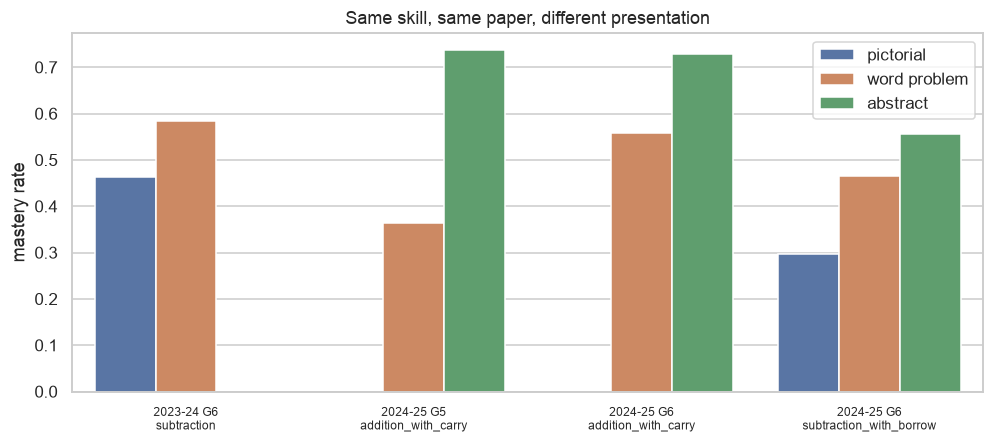

mode                                            abstract  pictorial  word problem  pictorial minus abstract  abstract minus word problem  pictorial minus word problem
file       competency  stem                                                                                                                                           
2023-24 G6 subtraction subtraction                   NaN      0.463         0.583                       NaN                          NaN                        -0.120
2024-25 G5 addition    addition_with_carry         0.737        NaN         0.364                       NaN                        0.373                           NaN
2024-25 G6 addition    addition_with_carry         0.729        NaN         0.557                       NaN                        0.172                           NaN
           subtraction subtraction_with_borrow     0.557      0.298         0.466                    -0.259                        0.091                        -0.168

,count,mean,min,max
contrast,,,,
abstract minus word problem,3,0.212,0.091,0.373
pictorial minus abstract,1,-0.259,-0.259,-0.259
pictorial minus word problem,2,-0.144,-0.168,-0.120



Only 6 clean contrasts, so treat this as a direction with a size attached, not a precise coefficient.


In [35]:
pres_rows = []
for r in CLEAN_STEMS.itertuples():
    s = slice_file(r.Year, r.Grade)
    items_here = qmeta[(qmeta["file"] == r.file) & (qmeta["stem"] == r.stem)
                       & (qmeta["mode"] != "not marked")]
    for it in items_here.itertuples():
        if it.qno not in s.columns:
            continue
        v = s[it.qno].astype("float32").mask(lambda x: x < 0)
        pres_rows.append({"file": r.file, "competency": r.competency, "stem": r.stem,
                          "mode": it.mode, "qno": it.qno, "mastery": v.mean(), "n": v.notna().sum()})
pres = pd.DataFrame(pres_rows)

if len(pres):
    pres["label"] = pres["file"] + "\n" + pres["stem"].str.slice(0, 24)
    fig, ax = plt.subplots(figsize=(max(8, 2.3 * pres["label"].nunique()), 4.2))
    sns.barplot(data=pres, x="label", y="mastery", hue="mode", ax=ax)
    ax.set_title("Same skill, same paper, different presentation")
    ax.set_ylabel("mastery rate"); ax.set_xlabel(""); ax.legend(title="")
    plt.xticks(fontsize=8); plt.show()

    wide = pres.pivot_table(index=["file", "competency", "stem"], columns="mode", values="mastery")
    for a, b in [("pictorial", "abstract"), ("abstract", "word problem"),
                 ("pictorial", "word problem")]:
        if a in wide.columns and b in wide.columns:
            wide[f"{a} minus {b}"] = wide[a] - wide[b]
    display(wide.round(3))

    diffs = []
    for _, r in wide.iterrows():
        for a, b in [("pictorial", "abstract"), ("abstract", "word problem"),
                     ("pictorial", "word problem")]:
            if a in wide.columns and b in wide.columns and pd.notna(r.get(a)) and pd.notna(r.get(b)):
                diffs.append({"contrast": f"{a} minus {b}", "gap": r[a] - r[b]})
    diffs = pd.DataFrame(diffs)
    if len(diffs):
        display(diffs.groupby("contrast")["gap"].agg(["count", "mean", "min", "max"]).round(3))
        wp = diffs[diffs["contrast"].str.contains("word problem")]
        if len(wp):
            claim("Mean drop in mastery when the same skill is asked as a word problem",
                  wp["gap"].mean(), "7.2",
                  f"mean over {len(wp)} same skill same paper contrasts")
        print(f"\nOnly {len(diffs)} clean contrasts, so treat this as a direction with a size "
              "attached, not a precise coefficient.")

### 7.3 gender gap on complex problems

testing if girls lag in complex problem solving. word problems are the proxy for this. comparing gender gap on word problems vs plain versions.
strict version only uses skills with both formats on the same paper.

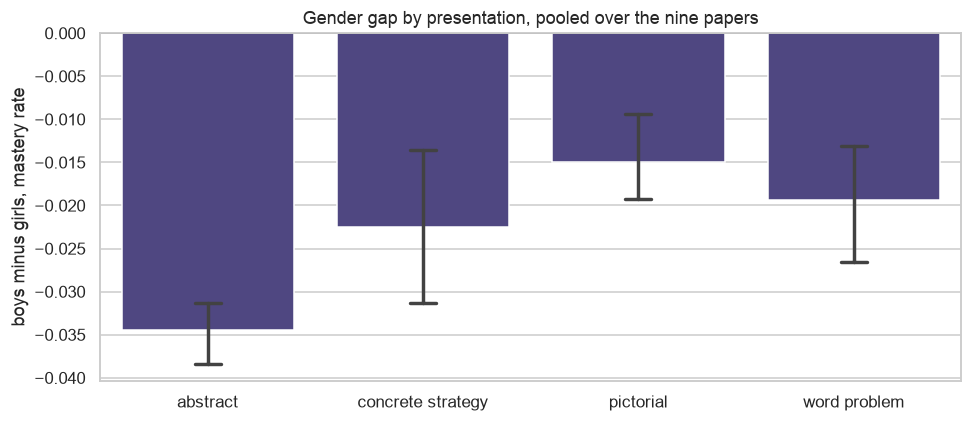

papers  mean_gap  worst
basis               mode                                      
all items           abstract                9    -0.034 -0.028
                    concrete strategy       5    -0.023 -0.005
                    pictorial               9    -0.015  0.006
                    word problem            6    -0.019 -0.007
matched skills only abstract                2    -0.031 -0.031
                    pictorial               2    -0.006 -0.003
                    word problem            3    -0.024 -0.010


Gap on abstract items: -0.034. Gap on word problems: -0.019. Difference: +0.015.
So the gap widens when the same arithmetic is wrapped in language. That points at reading and comprehension support rather than more maths drill.


In [36]:
def mode_scores(year, grade, restrict_stems=None):
    # per child mode fraction
    s = slice_file(year, grade)
    meta = qmeta[qmeta["file"] == f"{year} G{grade}"]
    if restrict_stems is not None:
        meta = meta[meta["stem"].isin(restrict_stems)]
    out = s[["Gender", "District", "Grade", "Year"]].copy()
    got = False
    for mode, grp in meta[meta["mode"] != "not marked"].groupby("mode"):
        cols = [q for q in grp["qno"] if q in s.columns]
        if not cols:
            continue
        out[mode] = s[cols].astype("float32").mask(lambda x: x < 0).mean(axis=1)
        got = True
    return out if got else None

rows = []
for (y, g) in FILES:
    stems = CLEAN_STEMS.loc[CLEAN_STEMS["file"] == f"{y} G{g}", "stem"].tolist()
    for tag, restrict in [("all items", None), ("matched skills only", stems or None)]:
        if tag == "matched skills only" and not stems:
            continue
        ms = mode_scores(y, g, restrict)
        if ms is None:
            continue
        for mode in [c for c in ms.columns if c not in ("Gender", "District", "Grade", "Year")]:
            m = ms.loc[ms["Gender"] == "M", mode].dropna()
            f = ms.loc[ms["Gender"] == "F", mode].dropna()
            if len(m) < 50 or len(f) < 50:
                continue
            d, lo, hi = gap_ci(m, f)
            rows.append({"basis": tag, "file": f"{y} G{g}", "mode": mode,
                         "boys": m.mean(), "girls": f.mean(), "gap": d, "lo": lo, "hi": hi})
gm = pd.DataFrame(rows)

if len(gm):
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(data=gm[gm["basis"] == "all items"], x="mode", y="gap", ax=ax,
                errorbar=("ci", 95), capsize=.12, color="darkslateblue")
    ax.axhline(0, color="black", lw=1)
    ax.set_title("Gender gap by presentation, pooled over the nine papers")
    ax.set_ylabel("boys minus girls, mastery rate"); ax.set_xlabel("")
    plt.show()

    summ = (gm.groupby(["basis", "mode"])["gap"]
            .agg(papers="count", mean_gap="mean", worst="max").round(4))
    display(summ)

    ai = gm[(gm["basis"] == "all items")]
    if {"word problem", "abstract"}.issubset(set(ai["mode"])):
        w = ai.loc[ai["mode"] == "word problem", "gap"].mean()
        a = ai.loc[ai["mode"] == "abstract", "gap"].mean()
        print(f"\nGap on abstract items: {a:+.3f}. Gap on word problems: {w:+.3f}. "
              f"Difference: {w - a:+.3f}.")
        claim("Difference between the gender gap on word problems and on abstract items",
              w - a, "7.3", "mean over papers of (gap on word problems) minus (gap on abstract items)")
        if w > a:
            print("So the gap widens when the same arithmetic is wrapped in language. That "
                  "points at reading and comprehension support rather than more maths drill.")

### 7.4 regrouping cliff

kids often struggle with carrying/borrowing. keeping presentation identical to isolate regrouping. dropping pairs where both change.

In [37]:
clean_pairs, confounded = [], []
for (y, g), m in MAPS.items():
    meta = qmeta[qmeta["file"] == f"{y} G{g}"]
    s = slice_file(y, g)
    for fam in ["carry", "borrow", "remainder"]:
        pool = meta[meta["regroup_family"] == fam]
        easy = pool[pool["regroup_level"] == "without"]
        hard = pool[pool["regroup_level"] == "with"]
        for a in easy.itertuples():
            for b in hard.itertuples():
                if a.qno not in s.columns or b.qno not in s.columns:
                    continue
                rec = {"file": f"{y} G{g}", "Year": y, "Grade": g, "family": fam,
                       "competency": a.competency, "easy_q": a.qno, "hard_q": b.qno,
                       "easy_name": a.question_name, "hard_name": b.question_name,
                       "easy_mode": a.mode, "hard_mode": b.mode}
                if a.mode != b.mode:
                    confounded.append(rec)
                    continue
                v = s[[a.qno, b.qno]].astype("float32").mask(lambda x: x < 0).dropna()
                rec.update({"p_without": v[a.qno].mean(), "p_with": v[b.qno].mean(),
                            "still_right_with": v.loc[v[a.qno] == 1, b.qno].mean(),
                            "lost_to_regrouping": ((v[a.qno] == 1) & (v[b.qno] == 0)).mean(),
                            "n": len(v)})
                clean_pairs.append(rec)

clean = pd.DataFrame(clean_pairs)
conf = pd.DataFrame(confounded)
print(f"{len(clean)} usable pairs, {len(conf)} thrown out because presentation moved too")
if len(conf):
    display(conf[["file", "competency", "easy_name", "easy_mode", "hard_name", "hard_mode"]]
            .reset_index(drop=True))

3 usable pairs, 3 thrown out because presentation moved too


,file,competency,easy_name,easy_mode,hard_name,hard_mode
0,2024-25 G4,addition,addition_without_carry_(seeing_pictures),pictorial,addition_with_carry_(abstract),abstract
1,2024-25 G4,subtraction,subtraction_without_borrow_(seeing_pictures),pictorial,subtraction_with_borrow_(abstract),abstract
2,2024-25 G5,subtraction,subtraction_without_borrow_(seeing_picture),pictorial,subtraction_with_borrow_(abstract),abstract


,file,competency,family,easy_q,hard_q,easy_mode,p_without,p_with,still_right_with,lost_to_regrouping,n
0,2022-23 G4,subtraction,borrow,Q7,Q8,abstract,0.413,0.440,0.655,0.143,104015
1,2022-23 G5,subtraction,borrow,Q6,Q7,abstract,0.472,0.538,0.717,0.134,113164
2,2022-23 G6,addition,carry,Q5,Q6,abstract,0.844,0.719,0.805,0.165,95523


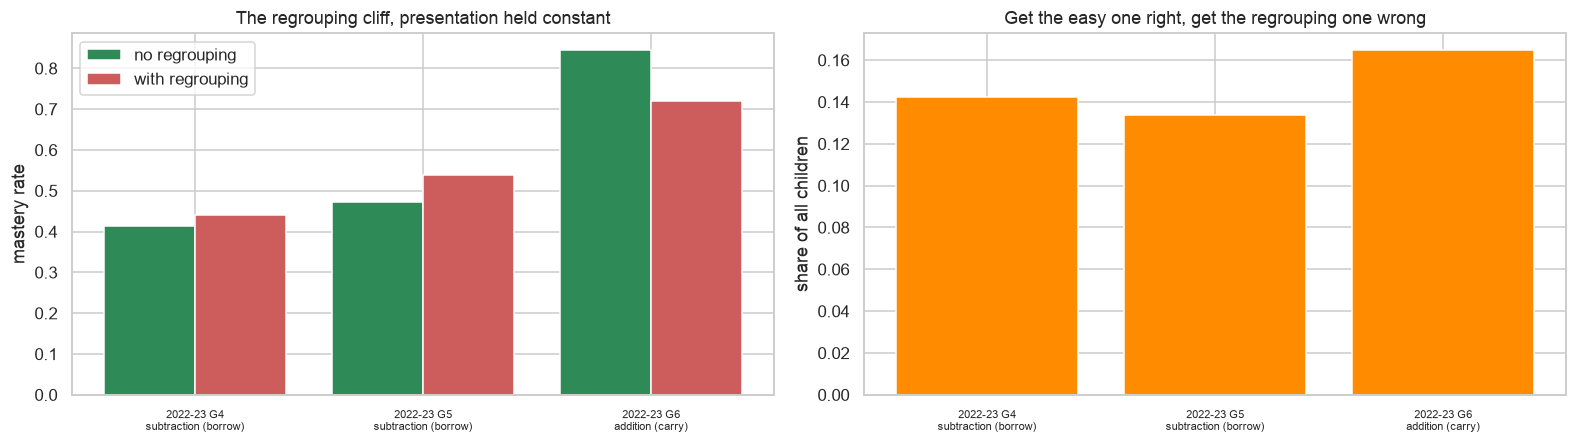

Average drop attributable to regrouping alone: 1.1%
Average share of children who clear the item without regrouping and then fail the one with it: 14.7%
That group is the specific target: they have the operation, they do not have the regrouping procedure. It is a narrow, teachable gap.


In [38]:
if len(clean):
    display(clean[["file", "competency", "family", "easy_q", "hard_q", "easy_mode",
                   "p_without", "p_with", "still_right_with", "lost_to_regrouping", "n"]]
            .round(3).reset_index(drop=True))

    clean["label"] = clean["file"] + "\n" + clean["competency"] + " (" + clean["family"] + ")"
    x = np.arange(len(clean))
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.2))
    axes[0].bar(x - .2, clean["p_without"], .4, label="no regrouping", color="seagreen")
    axes[0].bar(x + .2, clean["p_with"], .4, label="with regrouping", color="indianred")
    axes[0].set_xticks(x); axes[0].set_xticklabels(clean["label"], fontsize=7)
    axes[0].set_ylabel("mastery rate"); axes[0].legend()
    axes[0].set_title("The regrouping cliff, presentation held constant")

    axes[1].bar(x, clean["lost_to_regrouping"], color="darkorange")
    axes[1].set_xticks(x); axes[1].set_xticklabels(clean["label"], fontsize=7)
    axes[1].set_ylabel("share of all children")
    axes[1].set_title("Get the easy one right, get the regrouping one wrong")
    plt.show()

    drop = (clean["p_without"] - clean["p_with"]).mean()
    lost = clean["lost_to_regrouping"].mean()
    print(f"Average drop attributable to regrouping alone: {drop:.1%}")
    print(f"Average share of children who clear the item without regrouping and then fail "
          f"the one with it: {lost:.1%}")
    print("That group is the specific target: they have the operation, they do not have the "
          "regrouping procedure. It is a narrow, teachable gap.")
    claim("Mean fall in mastery attributable to regrouping with presentation held constant",
          drop, "7.4", f"mean over {len(clean)} same mode with/without pairs")

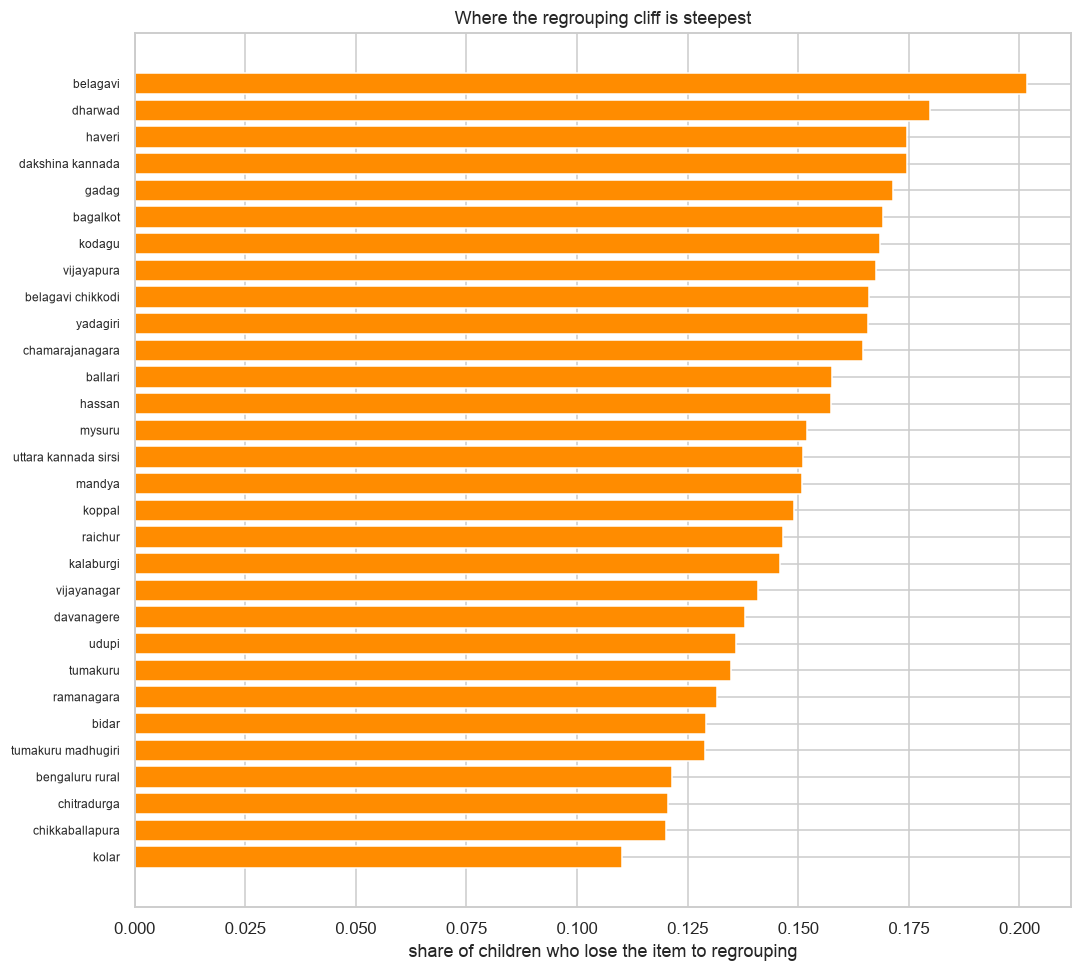

,lost,kept
District,,
vijayapura,0.168,0.771
kodagu,0.168,0.693
bagalkot,0.169,0.718
gadag,0.171,0.669
dakshina kannada,0.175,0.749
haveri,0.175,0.745
dharwad,0.180,0.734
belagavi,0.202,0.732


A district high on this list but not on the overall weak list has children who know the operation. That needs a different lesson from a district weak on both.


In [39]:
if len(clean):
    parts = []
    for r in clean.itertuples():
        s = slice_file(r.Year, r.Grade)[[r.easy_q, r.hard_q, "District"]]
        s = s[(s[r.easy_q] >= 0) & (s[r.hard_q] >= 0)]
        d = (s.groupby("District", observed=True)
               .apply(lambda t: pd.Series({
                   "lost": ((t[r.easy_q] == 1) & (t[r.hard_q] == 0)).mean(),
                   "kept": t.loc[t[r.easy_q] == 1, r.hard_q].mean()}))
               .reset_index())
        parts.append(d)
    dl = pd.concat(parts).groupby("District", observed=True)[["lost", "kept"]].mean()
    dl = dl.sort_values("lost")

    fig, ax = plt.subplots(figsize=(10, max(4, .3 * len(dl))))
    ax.barh(dl.index, dl["lost"], color="darkorange")
    ax.set_xlabel("share of children who lose the item to regrouping")
    ax.set_title("Where the regrouping cliff is steepest")
    ax.tick_params(axis="y", labelsize=8)
    plt.show()
    display(dl.round(3).tail(8))
    print("A district high on this list but not on the overall weak list has children who "
          "know the operation. That needs a different lesson from a district weak on both.")

### 7.5 non attempts

zeros at the end likely mean running out of time. measuring the size of this issue and which competencies sit at the end.

234,761 children (17.0%) have a run of 4 or more zeros at the end of the paper while scoring something earlier.


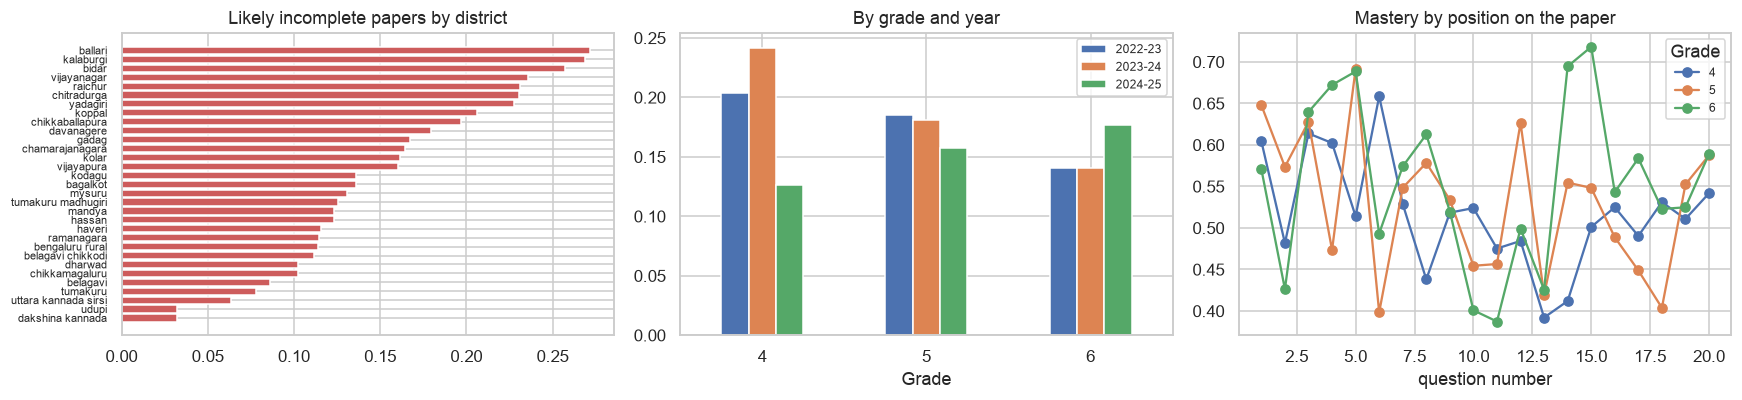

,file,last five questions cover
0,2022-23 G4,"measurement, shapes"
1,2022-23 G5,"measurement, shapes"
2,2022-23 G6,"addition, measurement, shapes"
3,2023-24 G4,"data handling, measurement, shapes"
4,2023-24 G5,"data handling, measurement, shapes"
5,2023-24 G6,"data handling, measurement, shapes"
6,2024-25 G4,"measurement, shapes"
7,2024-25 G5,"data handling, measurement, shapes"
8,2024-25 G6,"data handling, measurement, mensuration, shapes"


Competencies sitting at the end of a paper will read weaker than they are, and which ones those are changes from paper to paper.


In [40]:
MIN_RUN = 4
tz, tail = [], []
for (y, g) in FILES:
    s = slice_file(y, g)
    qs = qs_of(y, g)
    arr = s[qs].to_numpy()
    run = np.zeros(len(arr), dtype=int)
    nz = arr != 0
    for i in range(len(arr)):
        idx = np.flatnonzero(nz[i])
        run[i] = len(qs) - (idx[-1] + 1) if len(idx) else len(qs)
    tz.append(pd.DataFrame({"file": f"{y} G{g}", "Grade": g, "Year": y,
                            "District": s["District"].values, "run": run,
                            "suspect": (run >= MIN_RUN) & (s["Score"].values > 0)}))
    m = MAPS[(y, g)]
    tail.append({"file": f"{y} G{g}",
                 "last five questions cover": ", ".join(sorted(
                     m[m["qno"].isin(qs[-5:])]["competency"].unique()))})
tz = pd.concat(tz, ignore_index=True)

print(f"{tz['suspect'].sum():,} children ({tz['suspect'].mean():.1%}) have a run of "
      f"{MIN_RUN} or more zeros at the end of the paper while scoring something earlier.")

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
bd = tz.groupby("District", observed=True)["suspect"].mean().sort_values()
axes[0].barh(bd.index, bd.values, color="indianred")
axes[0].set_title("Likely incomplete papers by district"); axes[0].tick_params(axis="y", labelsize=7)

tz.groupby(["Grade", "Year"])["suspect"].mean().unstack().plot(kind="bar", ax=axes[1])
axes[1].set_title("By grade and year"); axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=8, title="")

pos = []
for (y, g) in FILES:
    s = slice_file(y, g); qs = qs_of(y, g)
    v = s[qs].astype("float32").mask(lambda x: x < 0).mean()
    pos.append(pd.DataFrame({"position": range(1, len(qs) + 1), "mastery": v.values, "Grade": g}))
pos = pd.concat(pos).groupby(["position", "Grade"])["mastery"].mean().unstack()
pos.plot(marker="o", ax=axes[2])
axes[2].set_title("Mastery by position on the paper"); axes[2].set_xlabel("question number")
axes[2].legend(title="Grade", fontsize=8)
plt.show()

display(pd.DataFrame(tail))
print("Competencies sitting at the end of a paper will read weaker than they are, and "
      "which ones those are changes from paper to paper.")
claim("Share of children showing a run of trailing zeros consistent with not finishing",
      tz["suspect"].mean(), "7.5", f"run of >= {MIN_RUN} zeros at the end with a non zero total")

### 7.6 noise check

checking consistency when a paper asks the same thing twice. low agreement reflects test noise, capping the weight of single items.

,file,skill,a,b,p_a,p_b,agree,phi,n
0,2022-23 G4,long_division_without_remainder,Q13,Q14,0.384,0.350,0.840,0.658,104015
1,2022-23 G4,long_multiplication(abstract),Q10,Q11,0.530,0.532,0.866,0.731,104015
2,2022-23 G5,long_division_without_remainder,Q12,Q13,0.516,0.457,0.833,0.671,113164
3,2022-23 G5,long_multiplication(abstract),Q9,Q10,0.644,0.516,0.759,0.532,113164
4,2022-23 G5,measure_length_using_standard_unit,Q16,Q19,0.282,0.606,0.582,0.291,113164
5,2022-23 G6,long_multiplication(abstract),Q10,Q11,0.473,0.546,0.734,0.476,95523
6,2022-23 G6,subtraction_with_borrow(abstract),Q8,Q9,0.789,0.555,0.682,0.371,95523
7,2023-24 G4,long_multiplication(abstract),Q9,Q10,0.543,0.470,0.803,0.614,156940
8,2023-24 G6,long_multiplication(abstract),Q9,Q10,0.548,0.421,0.743,0.511,151938
9,2024-25 G4,comparision,Q3,Q4,0.689,0.675,0.727,0.370,209867


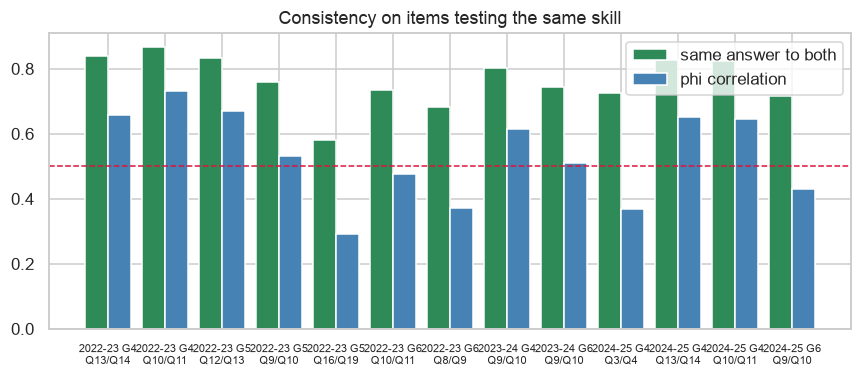

Mean phi across repeated items: 0.53. Anything well under 0.5 means single item competency scores should be read with a wide error bar.


In [41]:
rows = []
for (y, g), m in MAPS.items():
    mm = m.assign(name=m["qname"].map(norm_name))
    dup = mm[mm.duplicated("name", keep=False)]
    if dup.empty:
        continue
    s = slice_file(y, g)
    for nm, grp in dup.groupby("name"):
        for a, b in combinations([q for q in grp["qno"] if q in s.columns], 2):
            v = s[[a, b]].astype("float32").mask(lambda x: x < 0).dropna()
            if v.empty:
                continue
            rows.append({"file": f"{y} G{g}", "skill": nm, "a": a, "b": b,
                         "p_a": v[a].mean(), "p_b": v[b].mean(),
                         "agree": (v[a] == v[b]).mean(),
                         "phi": v[a].corr(v[b]), "n": len(v)})
par = pd.DataFrame(rows)

if par.empty:
    print("No paper repeats a question name, so this check is not available.")
else:
    display(par.round(3))
    fig, ax = plt.subplots(figsize=(8, 3.6))
    x = np.arange(len(par))
    ax.bar(x - .2, par["agree"], .4, label="same answer to both", color="seagreen")
    ax.bar(x + .2, par["phi"], .4, label="phi correlation", color="steelblue")
    ax.axhline(.5, color="crimson", ls="--", lw=1)
    ax.set_xticks(x); ax.set_xticklabels([f"{r.file}\n{r.a}/{r.b}" for r in par.itertuples()],
                                         fontsize=7)
    ax.legend(); ax.set_title("Consistency on items testing the same skill")
    plt.show()
    print(f"Mean phi across repeated items: {par['phi'].mean():.2f}. Anything well under "
          "0.5 means single item competency scores should be read with a wide error bar.")

### 7.7 skill gates

checking if competency A gates competency B. big difference means A is a prerequisite. helps prioritize what to teach first.

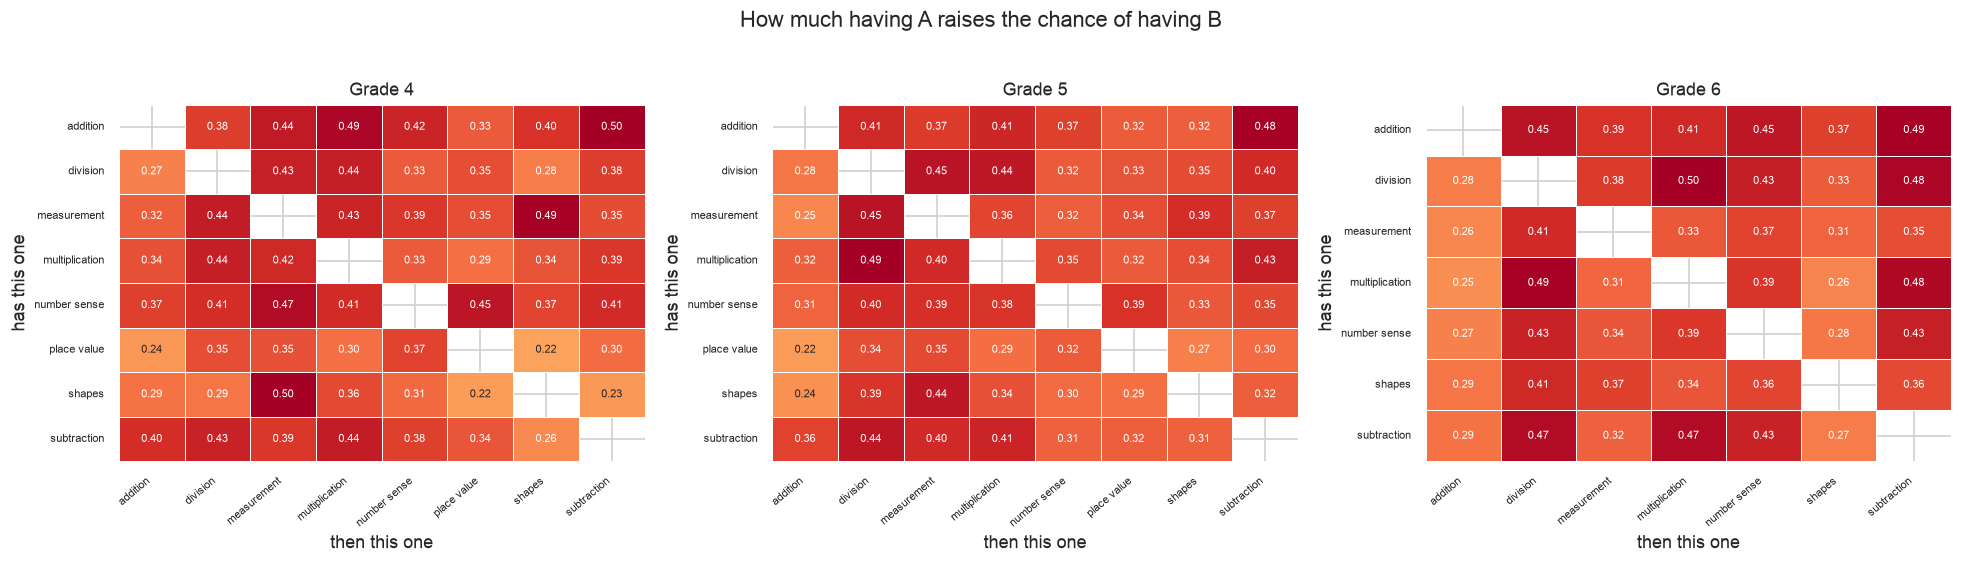


grade 4, teach this first order:


,gates other competencies by,own mastery,priority
division,0.353,0.458,0.191
multiplication,0.365,0.533,0.170
measurement,0.397,0.580,0.166
place value,0.304,0.562,0.133



grade 5, teach this first order:


,gates other competencies by,own mastery,priority
measurement,0.354,0.514,0.172
division,0.368,0.535,0.171
subtraction,0.366,0.649,0.128
place value,0.298,0.574,0.127



grade 6, teach this first order:


,gates other competencies by,own mastery,priority
multiplication,0.362,0.442,0.202
subtraction,0.376,0.533,0.176
division,0.400,0.580,0.168
number sense,0.355,0.555,0.158


priority = how much it gates, times how much room it still has. This is an association, not proof of a prerequisite, but it is the ordering the data supports.


In [42]:
mastered = cs[["Grade"]].copy()
for c in COMP_COLS:
    # missing != not mastered
    mastered[c] = cs[c].ge(MASTERED).where(cs[c].notna())

lift, leverage = {}, {}
for g in GRADES:
    sub = mastered[mastered["Grade"] == g]
    comps = [c for c in stable_in_grade[g] if c in COMP_COLS and sub[c].notna().any()]
    have = sub[comps].astype("float32")
    have = have.dropna()
    if len(have) < 200 or len(comps) < 3:
        continue
    L = pd.DataFrame(index=comps, columns=comps, dtype=float)
    for a in comps:
        yes = have[a] == 1
        if yes.sum() < 50 or (~yes).sum() < 50:
            continue
        for b in comps:
            if a != b:
                L.loc[a, b] = have.loc[yes, b].mean() - have.loc[~yes, b].mean()
    lift[g] = L
    lev = pd.DataFrame({"gates other competencies by": L.mean(axis=1),
                        "own mastery": have.mean()})
    lev["priority"] = lev["gates other competencies by"] * (1 - lev["own mastery"])
    leverage[g] = lev.sort_values("priority", ascending=False)

if lift:
    fig, axes = plt.subplots(1, len(lift), figsize=(6 * len(lift), 5), squeeze=False)
    for ax, (g, L) in zip(axes[0], sorted(lift.items())):
        sns.heatmap(L.astype(float), annot=True, fmt=".2f", cmap="RdYlBu_r", center=0,
                    linewidths=.4, cbar=False, ax=ax, annot_kws={"fontsize": 7})
        ax.set_title(f"Grade {g}")
        ax.set_xlabel("then this one"); ax.set_ylabel("has this one")
        ax.tick_params(labelsize=7)
        plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
    plt.suptitle("How much having A raises the chance of having B", y=1.02)
    plt.show()

    for g, lev in sorted(leverage.items()):
        print(f"\ngrade {g}, teach this first order:")
        display(lev.round(3).head(4))
    print("priority = how much it gates, times how much room it still has. "
          "This is an association, not proof of a prerequisite, but it is the ordering the "
          "data supports.")

## 8. who improved & overperformers

finding blocks that improved over three years, and identifying overperformers.

### 8.1 blocks that moved

first year vs last year per grade, only for common GPs. intervals on difference show real movement.

130 blocks have enough children in both 2022-23 and 2024-25 to compare
111 of them moved by more than sampling noise (5 up, 106 down)


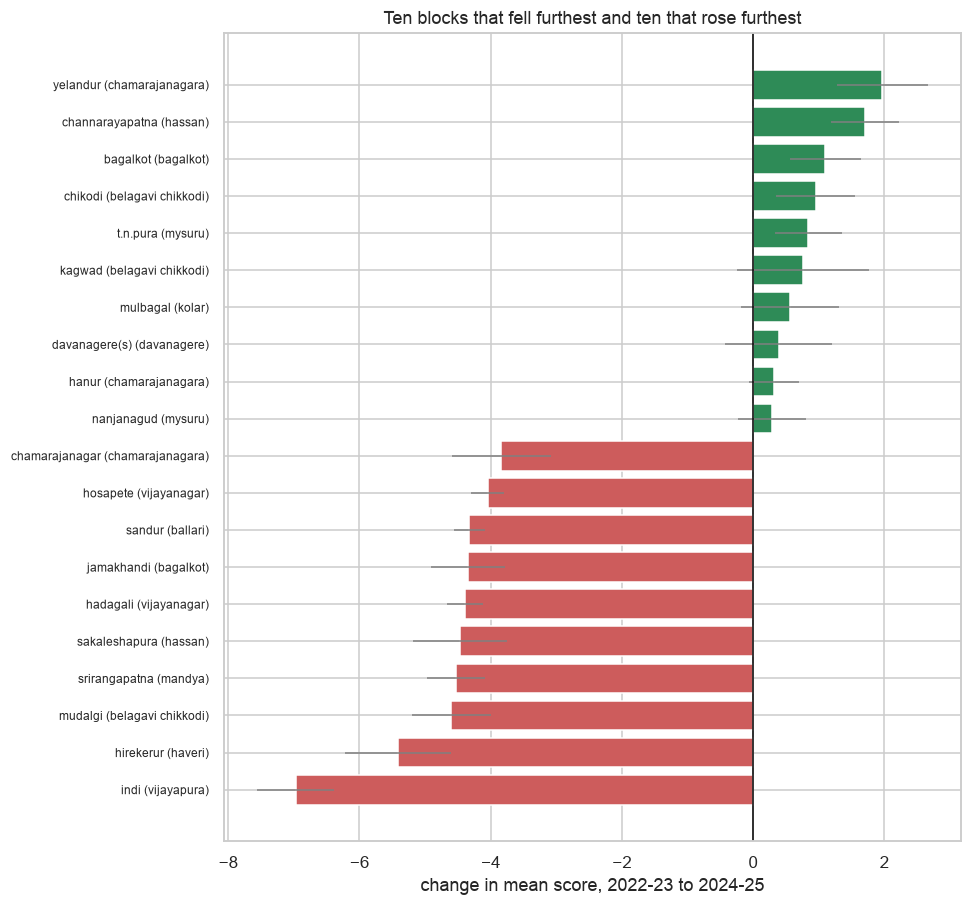

,District,Block,n first year,n last year,first,last,change,lo,hi,real move
48,davanagere,davanagere(s),318,310,11.887,12.281,0.394,-0.423,1.210,False
88,kolar,mulbagal,499,557,11.553,12.120,0.567,-0.179,1.314,False
19,belagavi chikkodi,kagwad,205,252,10.863,11.623,0.760,-0.247,1.766,False
101,mysuru,t.n.pura,979,840,11.061,11.907,0.846,0.332,1.360,True
16,belagavi chikkodi,chikodi,241,300,15.942,16.897,0.955,0.354,1.556,True
1,bagalkot,bagalkot,332,560,15.166,16.270,1.104,0.558,1.650,True
66,hassan,channarayapatna,767,766,13.252,14.960,1.708,1.184,2.232,True
34,chamarajanagara,yelandur,459,442,8.913,10.885,1.972,1.278,2.666,True



Blocks that rose are the places to go and look at. Whatever they did is already working inside this system, under this budget, with these teachers.


In [45]:
base = df[df["GP ID"].isin(COMMON_GPS)] if not COVERAGE_STABLE else df
y0, y1 = YEARS[0], YEARS[-1]

rows = []
for (d, b), sub in base.groupby(["District", "Block"], observed=True):
    a = sub.loc[sub["Year"] == y0, "Score"]
    z = sub.loc[sub["Year"] == y1, "Score"]
    if len(a) < MIN_BLOCK or len(z) < MIN_BLOCK:
        continue
    diff, lo, hi = gap_ci(z, a)
    rows.append({"District": d, "Block": b, "n first year": len(a), "n last year": len(z),
                 "first": a.mean(), "last": z.mean(), "change": diff, "lo": lo, "hi": hi,
                 "real move": not (lo <= 0 <= hi)})
BLOCK_COLS = ["District", "Block", "n first year", "n last year", "first",
              "last", "change", "lo", "hi", "real move"]
blocks = pd.DataFrame(rows, columns=BLOCK_COLS)
if len(blocks):
    blocks = blocks.sort_values("change")

print(f"{len(blocks)} blocks have enough children in both {y0} and {y1} to compare")
if not len(blocks):
    print(f"No block clears MIN_BLOCK={MIN_BLOCK} children in both years, so there is "
          f"nothing to compare here. Either lower MIN_BLOCK or say in the report that "
          f"block level change cannot be measured on this coverage.")
else:
  print(f"{int(blocks['real move'].sum())} of them moved by more than sampling noise "
        f"({blocks.loc[blocks['real move'] & (blocks['change'] > 0)].shape[0]} up, "
        f"{blocks.loc[blocks['real move'] & (blocks['change'] < 0)].shape[0]} down)")

if len(blocks):
    show = pd.concat([blocks.head(10), blocks.tail(10)])
    fig, ax = plt.subplots(figsize=(9, .32 * len(show) + 2))
    colors = ["indianred" if c < 0 else "seagreen" for c in show["change"]]
    ax.barh(show["Block"].astype(str) + " (" + show["District"].astype(str) + ")",
            show["change"],
            xerr=[show["change"] - show["lo"], show["hi"] - show["change"]],
            color=colors, error_kw={"lw": 1, "ecolor": "grey"})
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel(f"change in mean score, {y0} to {y1}")
    ax.set_title("Ten blocks that fell furthest and ten that rose furthest")
    ax.tick_params(axis="y", labelsize=8)
    plt.show()

    display(blocks.tail(8).round(3))
    claim("Number of blocks whose change between the first and last year is larger than "
          "sampling noise", int(blocks["real move"].sum()), "8.1",
          "95% interval on the difference of block means excludes zero")
    print("\nBlocks that rose are the places to go and look at. Whatever they did is already "
          "working inside this system, under this budget, with these teachers.")

### 8.2 GPs beating their block

ranking by raw score just finds rich districts. better to find GPs beating their own block since conditions are similar. scoring GP vs block and keeping ones that consistently overperform.

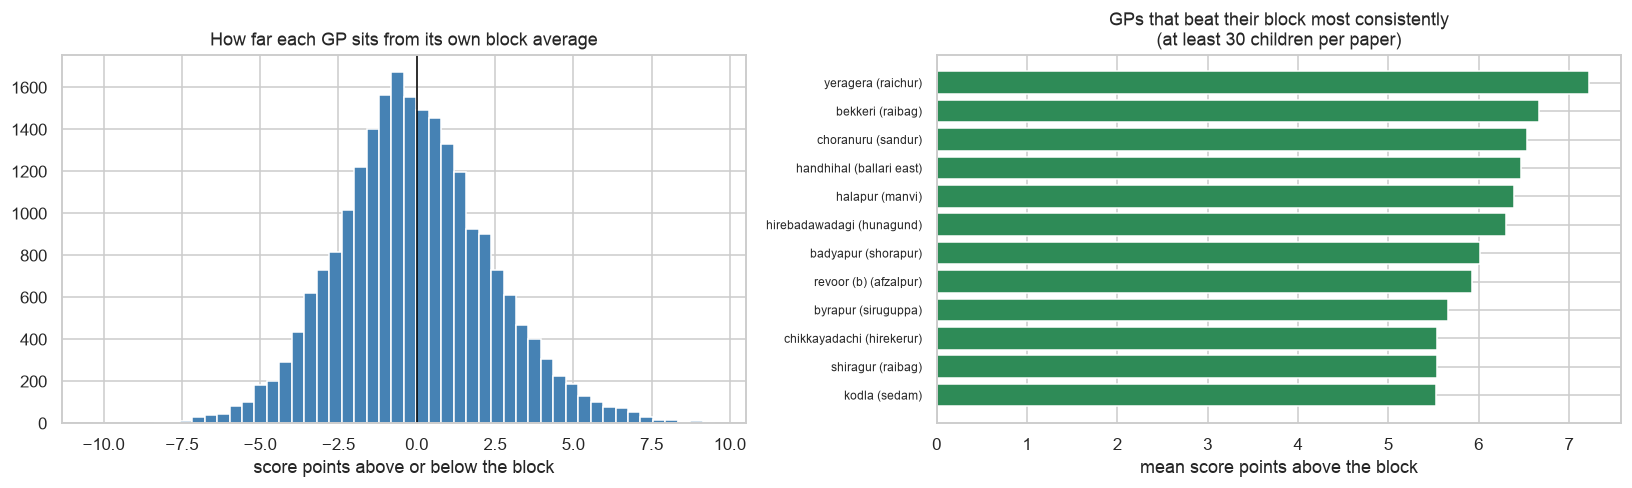

,GP ID,GP Name,District,Block,papers,mean_edge,times_above,children,always_above
0,6105,yeragera,raichur,raichur,9,7.219,9,598,True
1,1140,bekkeri,belagavi chikkodi,raibag,5,6.672,5,161,True
2,1675,choranuru,ballari,sandur,9,6.538,9,452,True
3,2406,handhihal,ballari,ballari east,9,6.463,9,462,True
4,2328,halapur,raichur,manvi,9,6.393,9,631,True
5,2618,hirebadawadagi,bagalkot,hunagund,4,6.299,4,139,True
6,917,badyapur,yadagiri,shorapur,6,6.015,6,332,True
7,5119,revoor (b),kalaburgi,afzalpur,9,5.929,9,439,True
8,1453,byrapur,ballari,siruguppa,9,5.661,9,551,True
9,213009444,chikkayadachi,haveri,hirekerur,4,5.540,4,143,True


375 GPs sit above their block average on every paper they appear in, out of 2844 with enough coverage to judge.

These are the visits worth making. A GP outperforming its own block is not explained by district wealth or by which district got the programme first.

The same list from the other end, GPs falling behind neighbours they resemble:


,GP ID,GP Name,District,Block,papers,mean_edge,times_above,children,always_above
0,1188,bellad bagewadi,belagavi chikkodi,hukkeri,6,-6.505,0,377,False
1,664,ammangi,belagavi chikkodi,hukkeri,6,-6.253,0,273,False
2,1823,dhannur,bagalkot,hunagund,6,-6.155,0,276,False
3,1114,bedkihal,belagavi chikkodi,nippani,4,-6.042,0,156,False
4,5485,soppadla,belagavi,soundatti,6,-5.469,0,255,False
5,1780,devanal,bagalkot,bagalkot,6,-5.104,0,268,False
6,4548,mulwad,vijayapura,basavan bagewadi,6,-5.102,0,473,False
7,4311,marevad,dharwad,dharwad,9,-5.054,0,565,False
8,5645,tavag,belagavi chikkodi,gokak,6,-4.883,0,318,False
9,3534,kelur,bagalkot,hunagund,6,-4.851,0,348,False


In [46]:
gp = (df.groupby(["file", "Year", "Grade", "Division", "District", "Block", "GP ID", "GP Name"],
                 observed=True)
        .agg(n=("Score", "size"), mean=("Score", "mean")).reset_index())
gp = gp[gp["n"] >= MIN_GP]

blockmean = (df.groupby(["file", "District", "Block"], observed=True)["Score"]
               .agg(["mean", "std"]).rename(columns={"mean": "blk_mean", "std": "blk_sd"})
               .reset_index())
gp = gp.merge(blockmean, on=["file", "District", "Block"])
gp["vs_block"] = gp["mean"] - gp["blk_mean"]
gp["z_vs_block"] = gp["vs_block"] / gp["blk_sd"].replace(0, np.nan)

consist = (gp.groupby(["GP ID", "GP Name", "District", "Block"], observed=True)
             .agg(papers=("vs_block", "size"), mean_edge=("vs_block", "mean"),
                  times_above=("vs_block", lambda s: int((s > 0).sum())),
                  children=("n", "sum"))
             .reset_index())
consist = consist[consist["papers"] >= max(3, len(FILES) // 2)]
consist["always_above"] = consist["times_above"] == consist["papers"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
axes[0].hist(gp["vs_block"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("How far each GP sits from its own block average")
axes[0].set_xlabel("score points above or below the block")

best = consist.sort_values("mean_edge", ascending=False).head(12)
axes[1].barh(best["GP Name"].astype(str) + " (" + best["Block"].astype(str) + ")",
             best["mean_edge"], color="seagreen")
axes[1].invert_yaxis()
axes[1].set_title(f"GPs that beat their block most consistently\n(at least {MIN_GP} children per paper)")
axes[1].set_xlabel("mean score points above the block")
axes[1].tick_params(axis="y", labelsize=8)
plt.show()

display(best.round(3).reset_index(drop=True))
n_always = int(consist["always_above"].sum())
print(f"{n_always} GPs sit above their block average on every paper they appear in, "
      f"out of {len(consist)} with enough coverage to judge.")
claim("Number of GPs above their own block average on every paper they appear in",
      n_always, "8.2", f"GP mean minus block mean per file, GPs with at least {MIN_GP} children")
print("\nThese are the visits worth making. A GP outperforming its own block is not "
      "explained by district wealth or by which district got the programme first.")

laggards = consist.sort_values("mean_edge").head(12)
print("\nThe same list from the other end, GPs falling behind neighbours they resemble:")
display(laggards.round(3).reset_index(drop=True))

## 9. exports

exporting summary tables at district, block, and GP level for the indices notebook and dashboard.

In [47]:
notes = [
    f"{len(df):,} children, {len(FILES)} papers, {len(YEARS)} years, grades {GRADES}",
    f"{len(COMPETENCIES)} competencies in total, {len(CORE)} of them on every paper",
    f"{len(COMMON_GPS):,} GPs appear in all nine papers out of {len(ALL_GPS):,} ever assessed",
    f"weakest shared core competency: {core_state.index[0]} at {core_state['mastery'].iloc[0]:.0%}",
    f"{df['below_floor'].mean():.1%} of children score below half the paper",
    f"{vd['between children in the same GP'].mean():.0f}% of score variance is within GP, "
    "not between places",
    f"{len(CLEAN_STEMS)} clean presentation comparisons and {len(clean)} clean regrouping "
    f"pairs available; {len(conf)} confounded pairs excluded",
]
for n in notes:
    print(" -", n)

 - 1,379,087 children, 9 papers, 3 years, grades [4, 5, 6]
 - 11 competencies in total, 7 of them on every paper
 - 2,360 GPs appear in all nine papers out of 5,034 ever assessed
 - weakest shared core competency: division at 43%
 - 41.8% of children score below half the paper
 - 67% of score variance is within GP, not between places
 - 4 clean presentation comparisons and 3 clean regrouping pairs available; 3 confounded pairs excluded


In [48]:
# export summary tables
district_tbl = (df.groupby("District", observed=True)
                  .agg(children=("Score", "size"), gps=("GP ID", "nunique"),
                       mean_score=("Score", "mean"), below_floor=("below_floor", "mean"))
                  .assign(mastery=lambda d: d["mean_score"] / 20)
                  .reset_index())
district_tbl["Division"] = district_tbl["District"].map(to_division)

block_tbl = (df.groupby(["Division", "District", "Block"], observed=True)
               .agg(children=("Score", "size"), gps=("GP ID", "nunique"),
                    mean_score=("Score", "mean"), below_floor=("below_floor", "mean"))
               .reset_index())

exports = {
    "district_summary.csv": district_tbl,
    "block_summary.csv": block_tbl,
    "gp_vs_block.csv": consist,
    "block_change.csv": blocks,
    "core_mastery_by_district.csv": mastery(cs, ["District"], CORE),
    "core_mastery_by_district_year.csv": mastery(cs, ["Year", "District"], CORE),
    "core_mastery_by_district_gender.csv": mastery(cs, ["District", "Gender"], CORE),
    "core_mastery_by_division.csv": mastery(cs, ["Division"], CORE),
    "mastery_by_grade_year.csv": mastery(cs, ["Grade", "Year"]),
    "competency_coverage.csv": covi.reset_index(),
    "competency_item_stability.csv": comp_stab,
    "question_metadata.csv": qmeta,
    "item_trend.csv": tracked,
    "gender_gap_by_mode.csv": gm,
    "central_vs_local_competencies.csv": quad.reset_index(),
    "variance_decomposition.csv": vd.reset_index().rename(columns={"index": "file"}),
    "coverage_by_file.csv": coverage,
}
if len(clean):
    exports["regrouping_clean_pairs.csv"] = clean
if len(conf):
    exports["regrouping_confounded_pairs.csv"] = conf
if len(pres):
    exports["presentation_mastery.csv"] = pres
if not par.empty:
    exports["parallel_items.csv"] = par

for name, table in exports.items():
    table.to_csv(OUT / name, index=False)

with open(OUT / "claims_draft.json", "w") as fh:
    json.dump(CLAIMS, fh, indent=2)

print(f"{len(exports)} tables written to {OUT}/")
for name in sorted(exports):
    print(f"  {name:38s} {len(exports[name]):>7,} rows")
print(f"\n{len(CLAIMS)} numbered claims logged to claims_draft.json for the report")

21 tables written to outputs/
  block_change.csv                           130 rows
  block_summary.csv                          168 rows
  central_vs_local_competencies.csv            7 rows
  competency_coverage.csv                     11 rows
  competency_item_stability.csv               31 rows
  core_mastery_by_district.csv               217 rows
  core_mastery_by_district_gender.csv        434 rows
  core_mastery_by_district_year.csv          602 rows
  core_mastery_by_division.csv                28 rows
  coverage_by_file.csv                         9 rows
  district_summary.csv                        31 rows
  gender_gap_by_mode.csv                      36 rows
  gp_vs_block.csv                          2,844 rows
  item_trend.csv                              88 rows
  mastery_by_grade_year.csv                   82 rows
  parallel_items.csv                          13 rows
  presentation_mastery.csv                     9 rows
  question_metadata.csv                      180 row

### key points
- zero can mean skipped. mastery = demonstrated mastery.
- no individual tracking across years, just cohort comparisons.
- papers are different instruments. raw scores aren't easily comparable. item level trends are safest.
- only using clean comparisons for presentation/regrouping effects.
- single item competencies are noisy.
- small GPs excluded from rankings, not aggregates.
- govt schools only, doesn't generalize to private or out of school kids.